# 🔥 QAYDH (القيظ) — Hyperspectral Heat-Risk Intelligence for Fast-Growing Gulf Cities
### Arab Youth Space Hackathon: 813 Challenge · Theme: *Urban Expansion, Land Use Change & Heat Risk* · Team **T0049**

**Problem statement.** We want to **map where a Gulf city has expanded (2014 → 2025), measure how hot each new and established district gets at peak summer, and identify the surface materials that drive that heat**, so that **municipal planners and urban-heat officers** can decide **where to deploy cool roofs, cool pavements, shade trees and heat-aware building codes first**.

**What this notebook produces (fully reproducible, open data only):**

| Layer | Data | Method | Validation |
|---|---|---|---|
| 1 · Urban expansion | Landsat 8/9 C2 L2 (30 m), 2014 & 2025 | Random-Forest land cover trained on ESA WorldCover 2021 + texture features | Spatial-block 5-fold CV vs. the official NDBI baseline; **independent** check vs. Impact Observatory LULC 2023 (+ change agreement 2017→2023) |
| 2 · Heat hazard | Landsat 8/9 surface temperature (ST_B10), summer 2025 | Cloud-masked median LST | LST by land-cover class, block-bootstrap CIs |
| 3 · Surface materials | **Planet Tanager hyperspectral** (open archive, CC-BY-4.0) | Broadband albedo, hydrocarbon index (asphalt, 1730 nm), carbonate/clay band depths, spectral material clusters | Tanager-vs-Landsat albedo agreement + automatic co-registration; **ΔR² test: does hyperspectral improve LST prediction?** |
| 4 · **People exposure** | WorldPop 2025 (100 m) + OpenStreetMap places where people are outdoors: mosques, bus stops, delivery-rider hubs, construction sites, schools, clinics | Population + outdoor-activity density per 300 m cell | Share of each outdoor group's places that fall in the hottest cells |
| 5 · Decision product | All of the above | 300 m Heat-Risk Priority Index = heat × **people** exposure × lack of greenery × new-district factor; a concrete action per cell (cool roof, shaded bus stop, shaded mosque walkway, rider cooling station, midday work-break enforcement, trees); cool-roof what-if in °C | Weight-sensitivity analysis; buildings-only vs people-aware ranking |

> Data access follows the PoC-phase rules: **only open multispectral data + Planet Tanager open archive**. No commercial, gIQ, 813 or MBZ-SAT data is used.

**Run order:** `Runtime → Run all` in Google Colab, or locally with `pip install -r requirements.txt` (≈15–30 min the first time, mostly downloads; raw data is cached in `data/`). Every figure is saved to `qaydh_outputs/` for the pitch deck, and every number to `qaydh_outputs/results.json`.

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:   # locally: pip install -r requirements.txt
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pystac-client", "planetary-computer", "odc-stac",
                           "rasterio", "h5py", "scikit-learn", "geopandas", "folium", "pyproj", "shapely", "matplotlib"])


## 0 · Configuration
Change only this cell. The defaults reproduce our submission: **Riyadh, Saudi Arabia** (Tanager scene `20250515_080954_16_4001`, 15 May 2025, the only Arab-region scene in the open *urban* archive). Note: official notebook 02 calls its first item “Riyadh”, but `20250407_035509_25_4001` is actually Ho Chi Minh City. We checked every footprint. To run on another city, set `TANAGER_ID` to another scene from the listing in step 1 — the whole pipeline follows the Tanager footprint automatically.

In [2]:
import os, re, json, math, warnings, datetime as dt
from urllib.parse import urljoin
import numpy as np, pandas as pd, requests, h5py
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy import ndimage as ndi
from scipy.ndimage import uniform_filter
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
import rasterio
from rasterio.crs import CRS
from rasterio.transform import from_bounds, Affine
from rasterio.warp import reproject, Resampling
warnings.filterwarnings("ignore", category=RuntimeWarning)

TEAM            = "T0049"
TANAGER_COLL    = "urban"
TANAGER_ID      = "20250515_080954_16_4001"   # Riyadh, 2025-05-15 (As Sali / east Riyadh)
COUNTRY_ISO3    = "SAU"                       # for WorldPop population (change with the city)
AOI_OVERRIDE    = None                        # e.g. [46.55, 24.55, 46.90, 24.90] to crop (lon/lat)
YEAR_BEFORE     = 2014                        # first full Landsat-8 year
YEAR_TRAIN      = 2021                        # matches ESA WorldCover 2021 labels
YEAR_INDEP      = 2023                        # independent check vs Impact Observatory LULC
YEAR_CHG_REF    = 2017                        # change-agreement check 2017 -> 2023 vs IO LULC
YEAR_AFTER      = 2025
LST_WINDOW      = ("2025-06-01", "2025-08-31")  # peak summer
MAX_CLOUD       = 20      # scene cloud %
MAX_SCENES      = 10      # lowest-cloud scenes per composite
BLOCK_PX        = 34      # ~1 km spatial blocks for CV (prevents neighbour leakage)
CELL_PX         = 10      # 10 x 30 m = 300 m decision cells
SEED            = 813
OUT             = "qaydh_outputs"; os.makedirs(OUT, exist_ok=True)
DATA            = "data"; os.makedirs(DATA, exist_ok=True)   # cached raw downloads (never committed)
RESULTS, PROV   = {}, []
def save_fig(name): plt.savefig(f"{OUT}/{name}.png", dpi=160, bbox_inches="tight")

/Users/nooraalhajeri/Projects/QAYDH/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1 · Toolbox (all analysis functions — read once, then just run)

In [3]:
EPS = 1e-6
def nd(a, b): return (a - b) / (a + b + EPS)

def utm_epsg(lon, lat):
    z = int((lon + 180) // 6) + 1
    return (32600 if lat >= 0 else 32700) + z

def local_std(a, size):
    a = np.where(np.isfinite(a), a, np.nanmean(a))
    m = uniform_filter(a, size); m2 = uniform_filter(a * a, size)
    return np.sqrt(np.clip(m2 - m * m, 0, None))

def block_ids(shape, block_px=BLOCK_PX):
    r, c = np.indices(shape); nb = int(np.ceil(shape[1] / block_px))
    return (r // block_px) * nb + (c // block_px)

def aggregate(a, f=CELL_PX, func=np.nanmean):
    H, W = a.shape; h, w = H // f, W // f
    return func(a[:h * f, :w * f].reshape(h, f, w, f), axis=(1, 3))

def remove_small(mask, min_px):
    lab, n = ndi.label(mask)
    if n == 0: return mask
    sizes = np.bincount(lab.ravel()); keep = sizes >= min_px; keep[0] = False
    return keep[lab]

def binary_metrics(t, p):
    t = np.asarray(t, bool); p = np.asarray(p, bool)
    tp = (t & p).sum(); fp = (~t & p).sum(); fn = (t & ~p).sum()
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    return dict(precision=prec, recall=rec, f1=2 * prec * rec / max(prec + rec, EPS), iou=tp / max(tp + fp + fn, 1))

def shift2d(a, dy, dx):
    out = np.full_like(a, np.nan, dtype="float32"); H, W = a.shape
    ys, yd = (slice(0, H - dy), slice(dy, H)) if dy >= 0 else (slice(-dy, H), slice(0, H + dy))
    xs, xd = (slice(0, W - dx), slice(dx, W)) if dx >= 0 else (slice(-dx, W), slice(0, W + dx))
    out[yd, xd] = a[ys, xs]; return out

def corr(a, b):
    ok = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[ok], b[ok])[0, 1] if ok.sum() > 100 else np.nan

# ---------------- Landsat ----------------
SR_BANDS = ["blue", "green", "red", "nir08", "swir16", "swir22"]
FEATS_LS = SR_BANDS + ["ndvi", "ndbi", "mndwi", "ndmi", "bsi", "albedo", "tex3", "tex7"]

def ls_clear(qa):
    qa = np.asarray(qa).astype(np.uint16)
    return ((qa & 1) == 0) & ((qa & 0b11110) == 0)      # fill, dilated cloud, cirrus, cloud, shadow

def sr_from_dn(dn):
    v = dn.astype("float32") * 2.75e-5 - 0.2
    v[(dn == 0) | (v < -0.05) | (v > 1.2)] = np.nan
    return v

def lst_from_dn(dn):
    v = dn.astype("float32") * 0.00341802 + 149.0 - 273.15
    v[(dn == 0) | (v < -20) | (v > 90)] = np.nan
    return v

def ls_features(c):
    f = {b: c[b] for b in SR_BANDS}
    f["ndvi"] = nd(c["nir08"], c["red"]); f["ndbi"] = nd(c["swir16"], c["nir08"])
    f["mndwi"] = nd(c["green"], c["swir16"]); f["ndmi"] = nd(c["nir08"], c["swir16"])   # water / surface moisture (irrigation)
    f["bsi"] = nd(c["swir16"] + c["red"], c["nir08"] + c["blue"])
    # Liang (2001) broadband shortwave albedo, Landsat-8 OLI form
    f["albedo"] = 0.356*c["blue"] + 0.130*c["red"] + 0.373*c["nir08"] + 0.085*c["swir16"] + 0.072*c["swir22"] - 0.0018
    f["tex3"] = local_std(c["nir08"], 3); f["tex7"] = local_std(c["nir08"], 7)   # urban texture vs smooth sand
    return f

def stack(f, names): return np.stack([f[n] for n in names], -1).astype("float32")

# ---------------- labels ----------------
CLASSES = ["Water", "Vegetation", "Built-up", "Bare/desert"]; BUILT = 2
def wc_to_class(a):            # ESA WorldCover 2021
    out = np.full(a.shape, -1, np.int8)
    out[a == 80] = 0; out[np.isin(a, [10, 20, 30, 40, 90, 95, 100])] = 1
    out[a == 50] = 2; out[np.isin(a, [60, 70])] = 3
    return out
def io_built(a): return np.where(a == 0, -1, (a == 7).astype(np.int8))   # Impact Observatory: 7 = built area

# ---------------- land-cover model ----------------
def train_lulc(F, y, n_per_class=6000, seed=SEED):
    X = stack(F, FEATS_LS); H, W, _ = X.shape
    ok = np.isfinite(X).all(-1) & (y >= 0)
    g = block_ids((H, W)); rng = np.random.default_rng(seed); idx = []
    for k in np.unique(y[ok]):
        cand = np.flatnonzero(ok.ravel() & (y.ravel() == k))
        idx.append(rng.choice(cand, min(n_per_class, len(cand)), replace=False))
    idx = np.concatenate(idx)
    Xs, ys, gs = X.reshape(-1, X.shape[-1])[idx], y.ravel()[idx], g.ravel()[idx]
    ndbi = F["ndbi"].ravel()[idx]; rows = []
    for fold, (tr, te) in enumerate(GroupKFold(5).split(Xs, ys, gs)):
        rf = RandomForestClassifier(200, min_samples_leaf=2, n_jobs=-1, class_weight="balanced_subsample",
                                    random_state=seed).fit(Xs[tr], ys[tr])
        p = rf.predict(Xs[te]); t = ys[te]
        rows.append(dict(fold=fold, model="QAYDH Random Forest", acc=accuracy_score(t, p),
                         macro_f1=f1_score(t, p, average="macro"), **binary_metrics(t == BUILT, p == BUILT)))
        rows.append(dict(fold=fold, model="Official nb02 rule (NDBI>0)", acc=np.nan, macro_f1=np.nan,
                         **binary_metrics(t == BUILT, ndbi[te] > 0)))
    rf = RandomForestClassifier(300, min_samples_leaf=2, n_jobs=-1, class_weight="balanced_subsample",
                                random_state=seed).fit(Xs, ys)
    return rf, pd.DataFrame(rows)

def predict_map(rf, F, chunk=400_000):
    X = stack(F, FEATS_LS); H, W, n = X.shape; X = X.reshape(-1, n)
    ok = np.isfinite(X).all(1); cls = np.full(len(X), -1, np.int8); pb = np.full(len(X), np.nan, "float32")
    ib = list(rf.classes_).index(BUILT); ii = np.flatnonzero(ok)
    for s in range(0, len(ii), chunk):
        j = ii[s:s + chunk]; pr = rf.predict_proba(X[j])
        cls[j] = rf.classes_[pr.argmax(1)]; pb[j] = pr[:, ib]
    return cls.reshape(H, W), pb.reshape(H, W)

# ---------------- Tanager hyperspectral ----------------
def is_bad_band(wl): return (1350 <= wl <= 1450) or (1800 <= wl <= 1950) or wl > 2450 or wl < 400

def tanager_georef(h5path, item, sr_key, shape):
    H, W = shape; a = item["assets"][sr_key]; p = {**item.get("properties", {}), **a}
    # (1) STAC projection extension
    code = p.get("proj:epsg") or (p.get("proj:code", "") or "").replace("EPSG:", "")
    if code and p.get("proj:transform") and tuple(p.get("proj:shape", ()))[-2:] == (H, W):
        t = p["proj:transform"]; return CRS.from_epsg(int(code)), Affine(*t[:6]), "STAC proj:transform"
    # (2) HDF-EOS StructMetadata
    with h5py.File(h5path, "r") as f:
        sm = f["HDFEOS INFORMATION/StructMetadata.0"][()] if "HDFEOS INFORMATION/StructMetadata.0" in f else None
    if sm is not None:
        sm = sm.decode() if isinstance(sm, (bytes, np.bytes_)) else str(sm); num = r"([-+\d\.eE]+)"
        ul = re.search(rf"UpperLeftPointMtrs=\({num},{num}\)", sm); lr = re.search(rf"LowerRightMtrs=\({num},{num}\)", sm)
        pr = re.search(r"Projection=(\w+)", sm); zc = re.search(r"ZoneCode=(-?\d+)", sm)
        if ul and lr and pr:
            x0, y0, x1, y1 = float(ul[1]), float(ul[2]), float(lr[1]), float(lr[2])
            if "UTM" in pr[1] and zc:
                z = int(zc[1]); crs = CRS.from_epsg(32600 + z if z > 0 else 32700 - z)
                return crs, from_bounds(x0, y1, x1, y0, W, H), "HDF-EOS StructMetadata (UTM)"
            if "GEO" in pr[1]:
                dms = lambda v: (abs(v) // 1e6 + (abs(v) % 1e6) // 1e3 / 60 + (abs(v) % 1e3) / 3600) * np.sign(v)
                return CRS.from_epsg(4326), from_bounds(dms(x0), dms(y1), dms(x1), dms(y0), W, H), "HDF-EOS StructMetadata (GEO)"
    # (3) ortho_visual GeoTIFF header (same ortho grid)
    for k in ["ortho_visual", "visual"]:
        if k in item["assets"]:
            try:
                with rasterio.open(item["assets"][k]["href"]) as src:
                    return src.crs, from_bounds(*src.bounds, W, H), f"{k} GeoTIFF bounds"
            except Exception as e: print("  visual georef failed:", e)
    b = item["bbox"]; return CRS.from_epsg(4326), from_bounds(*b, W, H), "STAC bbox (approximate!)"

def planck(wl_nm, T=5778.0):
    wl = wl_nm * 1e-9; h, c, k = 6.626e-34, 2.998e8, 1.381e-23
    return 1.0 / (wl ** 5 * (np.exp(h * c / (wl * k * T)) - 1))

def band_depth(R, wl, left, center, right):
    rl, rc, rr = R(left), R(center), R(right); wl_ = lambda t: wl[np.argmin(abs(wl - t))]
    l, c, r = wl_(left), wl_(center), wl_(right)
    cont = rl + (rr - rl) * (c - l) / (r - l)
    return 1 - rc / (cont + EPS)

def hydrocarbon_index(R, wl):   # Kühn et al. 2004: asphalt / plastics / oil-based roofing absorb at ~1730 nm
    w = lambda t: wl[np.argmin(abs(wl - t))]
    A, B, C = w(1705), w(1729), w(1741); RA, RB, RC = R(1705), R(1729), R(1741)
    return (B - A) * (RC - RA) / (C - A) + RA - RB

def tanager_cloud_test(R):
    # physics-based: thick cloud = very bright AND spectrally flat in VIS-SWIR; cirrus = reflectance in the 1380 nm absorption band
    thick = (R(470) > 0.35) & (R(470) / (R(1610) + EPS) > 0.9)
    cirrus = R(1380) > 0.015
    return thick | cirrus

def suggest_material(r):
    if r.ndvi > 0.35: return "Vegetation (irrigated / trees)"
    if r.albedo < 0.07: return "Water / deep shadow"
    if r.albedo < 0.16 and r.hi > 0: return "Dark impervious — asphalt-like (1730 nm hydrocarbon)"
    if r.albedo < 0.18: return "Dark impervious / shaded urban"
    if r.albedo > 0.38: return "High-albedo roofs / bright surfaces"
    if r.bd2330 > 0.04: return "Carbonate-rich: concrete / limestone sand"
    return "Mixed urban fabric / bare soil"

def to_grid(arr, src_crs, src_tr, dst_shape, dst_tr, dst_crs, method=Resampling.average):
    out = np.full(dst_shape, np.nan, "float32")
    reproject(np.asarray(arr, "float32"), out, src_transform=src_tr, src_crs=src_crs, dst_transform=dst_tr,
              dst_crs=dst_crs, resampling=method, src_nodata=np.nan, dst_nodata=np.nan)
    return out

def best_shift(a, ref, r=4):
    best = (corr(a, ref), 0, 0)
    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            c = corr(shift2d(a, dy, dx), ref)
            if c > best[0]: best = (c, dy, dx)
    return best

# ---------------- heat analysis ----------------
def cv_regress(X, y, groups, seed=SEED):
    r2, rmse = [], []
    for tr, te in GroupKFold(5).split(X, y, groups):
        m = RandomForestRegressor(100, min_samples_leaf=5, max_features=0.4, n_jobs=-1, random_state=seed).fit(X[tr], y[tr])
        p = m.predict(X[te]); r2.append(r2_score(y[te], p)); rmse.append(mean_squared_error(y[te], p) ** 0.5)
    return np.mean(r2), np.std(r2), np.mean(rmse)

def block_bootstrap_ols(X, y, groups, n_boot=300, seed=SEED):
    rng = np.random.default_rng(seed); ug = np.unique(groups); Xd = np.c_[np.ones(len(X)), X]
    beta = np.linalg.lstsq(Xd, y, rcond=None)[0]; bs = []
    by_g = {g: np.flatnonzero(groups == g) for g in ug}
    for _ in range(n_boot):
        j = np.concatenate([by_g[g] for g in rng.choice(ug, len(ug))])
        bs.append(np.linalg.lstsq(Xd[j], y[j], rcond=None)[0])
    bs = np.array(bs); return beta, np.percentile(bs, 2.5, 0), np.percentile(bs, 97.5, 0)

def pct_rank(a, mask):
    out = np.full(a.shape, np.nan); v = a[mask]
    out[mask] = pd.Series(v).rank(pct=True).values; return out

def hrpi(lst_c, expo_c, green_c, new_c, w=(1.0, 0.5, 0.5, 0.5), built_c=None, min_built=0.2):
    # Heat-Risk Priority Index: hazard x exposure x (lack of greenery) x (new-district penalty)
    # exposure = people exposure (0-1); the urban gate uses built-up fraction
    gate = expo_c if built_c is None else built_c
    urban = (gate >= min_built) & np.isfinite(lst_c)
    H = pct_rank(lst_c, urban)
    s = (H ** w[0]) * (np.clip(np.nan_to_num(expo_c), 0, None) ** w[1]) * (1 - w[2] * np.nan_to_num(green_c)) * (1 + w[3] * np.nan_to_num(new_c))
    s = np.where(urban, s, np.nan); return 100 * s / np.nanmax(s), urban

def recommend(row, k=3):
    # people-first actions (who is outside here?) then surface fixes (why is it hot?)
    acts = []
    g = lambda key: np.nan_to_num(row.get(key, 0) if row.get(key) is not None else 0)
    if g("construction") > 0:  acts.append("Enforce midday work break + site shade/water")
    if g("bus_stop") > 0:      acts.append("Shaded / cooled bus shelters")
    if g("mosque") > 0:        acts.append("Shaded walkways to mosque")
    if g("delivery") >= 2:     acts.append("Delivery-rider cooling & rest point")
    if g("vulnerable") > 0:    acts.append("Shade & cool roof at school/clinic")
    if g("dark_frac") >= 0.30: acts.append("Cool roofs & cool pavements")
    if g("green_frac") < 0.10: acts.append("Shade trees / green corridors")
    if g("new_frac") >= 0.20:  acts.append("Heat-aware design code for new district")
    if not acts: acts.append("Targeted inspection & shading of public spaces")
    return " + ".join(acts[:k])

def download(url, path, desc=""):
    if not os.path.exists(path):
        print(f"Downloading {desc or os.path.basename(path)} …")
        with requests.get(url, stream=True, timeout=900) as r:
            r.raise_for_status()
            with open(path + ".part", "wb") as fh:
                for ch in r.iter_content(1 << 20): fh.write(ch)
        os.replace(path + ".part", path)
    return path
print("toolbox ready")

toolbox ready


## 2 · Pick the Tanager scene → it defines the Area of Interest
Optional: the listing cell shows every open Tanager *urban* scene and flags those in the Arab region, so you can switch city (e.g. a UAE scene, if one exists) by changing `TANAGER_ID`.

In [4]:
TAN_BASE = f"https://www.planet.com/data/stac/tanager-core-imagery/{TANAGER_COLL}"
def list_tanager():
    col = requests.get(f"{TAN_BASE}/collection.json", timeout=60).json(); rows = []
    for l in col.get("links", []):
        if l.get("rel") != "item": continue
        try:
            it = requests.get(urljoin(f"{TAN_BASE}/collection.json", l["href"]), timeout=60).json()
            b = it["bbox"]; lon, lat = (b[0]+b[2])/2, (b[1]+b[3])/2
            rows.append(dict(id=it["id"], date=it["properties"]["datetime"][:10], lon=round(lon, 3), lat=round(lat, 3),
                             cloud=it["properties"].get("eo:cloud_cover"), arab_region=(-18 < lon < 60) and (10 < lat < 38)))
        except Exception as e: pass
    return pd.DataFrame(rows)
try:
    scenes = list_tanager(); display(scenes.sort_values("arab_region", ascending=False).head(40))
except Exception as e: print("Listing skipped:", e)

,id,date,lon,lat,cloud,arab_region
7,20250515_080954_16_4001,2025-05-15,46.856,24.576,None,True
0,20250225_153627_16_4001,2025-02-25,-70.218,11.661,None,False
44,20250313_143031_92_4001,2025-03-13,-58.622,-34.512,None,False
32,20250824_171853_67_4001,2025-08-24,-88.358,18.546,None,False
33,20250223_165542_16_4001,2025-02-23,-88.428,13.371,None,False
34,20250916_144245_51_4001,2025-09-16,-58.615,-34.537,None,False
35,20250916_144249_76_4001,2025-09-16,-58.658,-34.705,None,False
36,20250916_144254_01_4001,2025-09-16,-58.702,-34.872,None,False
37,20250724_144826_58_4001,2025-07-24,-58.584,-34.364,None,False
38,20250724_144830_83_4001,2025-07-24,-58.623,-34.517,None,False


In [5]:
tan_item = requests.get(f"{TAN_BASE}/{TANAGER_ID}/{TANAGER_ID}.json", timeout=60).json()
print("Location:", tan_item["properties"].get("location_description"))
AOI = AOI_OVERRIDE or tan_item["bbox"]
LON0, LAT0 = (AOI[0] + AOI[2]) / 2, (AOI[1] + AOI[3]) / 2
EPSG = utm_epsg(LON0, LAT0)
print("Tanager scene:", TANAGER_ID, tan_item["properties"]["datetime"])
print("AOI (lon/lat):", np.round(AOI, 4), "| UTM EPSG:", EPSG)
PROV.append(dict(source="Planet Tanager (open archive)", collection=f"tanager-core-imagery/{TANAGER_COLL}",
                 items=[TANAGER_ID], dates=[tan_item["properties"]["datetime"]], licence="CC-BY-4.0 © Planet Labs PBC"))
from IPython.display import Image; Image(url=tan_item["assets"]["thumbnail"]["href"], width=420)

Location: As Sali Municipality, Riyadh governorate, Riyadh Region, Saudi Arabia
Tanager scene: 20250515_080954_16_4001 2025-05-15T08:09:54.165094Z
AOI (lon/lat): [46.7421 24.4859 46.969  24.6651] | UTM EPSG: 32638


## 3 · Open data loaders (Microsoft Planetary Computer STAC)

In [6]:
import pystac_client, planetary_computer, odc.stac
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
GBOX = None   # common 30 m UTM grid for every layer

def stac_load(items, bands, resampling="nearest"):
    global GBOX
    kw = dict(bands=bands, groupby="solar_day", resampling=resampling, patch_url=planetary_computer.sign)
    kw["pool"] = 8   # threaded reads
    if GBOX is None:
        ds = odc.stac.load(items, crs=f"EPSG:{EPSG}", resolution=30, bbox=AOI, **kw); GBOX = ds.odc.geobox
    else:
        ds = odc.stac.load(items, geobox=GBOX, **kw)
    return ds

def search_landsat(start, end, n=MAX_SCENES):
    for cc in (MAX_CLOUD, 50):
        its = list(catalog.search(collections=["landsat-c2-l2"], bbox=AOI, datetime=f"{start}/{end}",
                  query={"platform": {"in": ["landsat-8", "landsat-9"]}, "eo:cloud_cover": {"lt": cc}}).item_collection())
        if len(its) >= 3: break
    return sorted(its, key=lambda i: i.properties["eo:cloud_cover"])[:n]

def sr_composite(year):
    its = search_landsat(f"{year}-01-01", f"{year}-12-31")
    ds = stac_load(its, SR_BANDS + ["qa_pixel"]); clear = ls_clear(ds["qa_pixel"].values)
    comp = {}
    for b in SR_BANDS:
        v = sr_from_dn(ds[b].values); v[~clear] = np.nan
        comp[b] = np.clip(np.nanmedian(v, 0), 0, None)
    PROV.append(dict(source="Landsat 8/9 C2 L2 surface reflectance", collection="landsat-c2-l2", items=[i.id for i in its],
                     dates=sorted(str(i.datetime.date()) for i in its), licence="Public domain (USGS)"))
    print(f"  {year}: {len(its)} scenes, median clear obs/pixel = {np.median(clear.sum(0)):.0f}")
    return comp

def item_year(i):
    d = i.datetime or dt.datetime.fromisoformat(i.properties["start_datetime"].replace("Z", "+00:00")); return d.year

def load_categorical(collection, asset, year, licence):
    its = [i for i in catalog.search(collections=[collection], bbox=AOI).item_collection() if item_year(i) == year]
    a = stac_load(its, [asset], resampling="mode")[asset].values; out = a[0].copy()
    for t in range(1, a.shape[0]): out = np.where(out == 0, a[t], out)
    PROV.append(dict(source=f"{collection} {year}", collection=collection, items=[i.id for i in its], dates=[str(year)], licence=licence))
    return out

## 4 · Layer 1 — Urban expansion 2014 → 2025
Landsat composites (cloud-masked median of the clearest scenes in each year) → Random-Forest classifier trained on ESA WorldCover 2021 → applied to every year on the same grid.

In [7]:
comps = {}
for yr in [YEAR_TRAIN, YEAR_BEFORE, YEAR_AFTER, YEAR_INDEP, YEAR_CHG_REF]:
    comps[yr] = sr_composite(yr)
FEAT = {yr: ls_features(c) for yr, c in comps.items()}
SHAPE = comps[YEAR_TRAIN]["red"].shape
TR, CRS_DST = GBOX.affine, CRS.from_user_input(str(GBOX.crs))
print("Grid:", SHAPE, "pixels @30 m  =", round(SHAPE[0]*SHAPE[1]*900/1e6, 1), "km²")

  2021: 10 scenes, median clear obs/pixel = 10


  2014: 10 scenes, median clear obs/pixel = 10


  2025: 10 scenes, median clear obs/pixel = 10


  2023: 10 scenes, median clear obs/pixel = 10


  2017: 10 scenes, median clear obs/pixel = 10
Grid: (673, 776) pixels @30 m  = 470.0 km²


In [8]:
wc = load_categorical("esa-worldcover", "map", 2021, "CC-BY-4.0 © ESA WorldCover project 2021")
y_wc = wc_to_class(wc)
rf, cv = train_lulc(FEAT[YEAR_TRAIN], y_wc)
cv_sum = cv.groupby("model")[["precision", "recall", "f1", "iou", "acc", "macro_f1"]].agg(["mean", "std"]).round(3)
display(cv_sum)
RESULTS["cv_built_f1_rf"]   = float(cv[cv.model.str.startswith("QAYDH")].f1.mean())
RESULTS["cv_built_f1_ndbi"] = float(cv[cv.model.str.startswith("Official")].f1.mean())
RESULTS["cv_built_iou_rf"]  = float(cv[cv.model.str.startswith("QAYDH")].iou.mean())
RESULTS["cv_macro_f1_rf"]   = float(cv[cv.model.str.startswith("QAYDH")].macro_f1.mean())
print("Note: CV test pixels are class-balanced samples from spatially held-out 1 km blocks.")

precision        recall            f1         \
                                 mean    std   mean    std   mean    std   
model                                                                      
Official nb02 rule (NDBI>0)     0.421  0.042  0.942  0.011  0.581  0.039   
QAYDH Random Forest             0.887  0.014  0.903  0.022  0.895  0.010   

                              iou           acc        macro_f1        
                             mean    std   mean    std     mean   std  
model                                                                  
Official nb02 rule (NDBI>0)  0.41  0.039    NaN    NaN      NaN   NaN  
QAYDH Random Forest          0.81  0.016  0.919  0.008     0.88  0.07

Note: CV test pixels are class-balanced samples from spatially held-out 1 km blocks.


In [9]:
LC, PB = {}, {}
for yr in comps: LC[yr], PB[yr] = predict_map(rf, FEAT[yr])

# Independent validation 1: our 2023 map vs Impact Observatory LULC 2023 (natural prevalence, all pixels)
io23 = io_built(load_categorical("io-lulc-annual-v02", "data", YEAR_INDEP, "CC-BY-4.0 © Impact Observatory, Microsoft, Esri"))
ok = (io23 >= 0) & (LC[YEAR_INDEP] >= 0)
ind_rf   = binary_metrics(io23[ok] == 1, LC[YEAR_INDEP][ok] == BUILT)
ind_ndbi = binary_metrics(io23[ok] == 1, FEAT[YEAR_INDEP]["ndbi"][ok] > 0)
indep = pd.DataFrame([dict(model="QAYDH RF", **ind_rf), dict(model="Official nb02 rule (NDBI>0)", **ind_ndbi)]).round(3)
display(indep); RESULTS["indep2023_built_f1_rf"] = ind_rf["f1"]; RESULTS["indep2023_built_f1_ndbi"] = ind_ndbi["f1"]

# Independent validation 2: change agreement 2017 -> 2023 vs IO LULC
io17 = io_built(load_categorical("io-lulc-annual-v02", "data", YEAR_CHG_REF, "CC-BY-4.0 © Impact Observatory, Microsoft, Esri"))
def new_urban(pb0, pb1, min_px=10): return remove_small((pb1 > 0.6) & (pb0 < 0.4), min_px)
ours_chg = new_urban(PB[YEAR_CHG_REF], PB[YEAR_INDEP]); ref_chg = remove_small((io23 == 1) & (io17 == 0), 10)
okc = (io23 >= 0) & (io17 >= 0) & np.isfinite(PB[YEAR_CHG_REF]) & np.isfinite(PB[YEAR_INDEP])
chg_m = binary_metrics(ref_chg[okc], ours_chg[okc]); RESULTS["change_agreement_2017_2023"] = chg_m
print("Change agreement 2017→2023 vs IO LULC:", {k: round(v, 3) for k, v in chg_m.items()})

,model,precision,recall,f1,iou
0,QAYDH RF,0.858,0.856,0.857,0.750
1,Official nb02 rule (NDBI>0),0.419,0.931,0.578,0.406


Change agreement 2017→2023 vs IO LULC: {'precision': np.float64(0.637), 'recall': np.float64(0.192), 'f1': np.float64(0.295), 'iou': np.float64(0.173)}


Built-up 2014: 167.0 km²  →  2025: 214.0 km² (+28%) | confident new urban: 32.6 km²


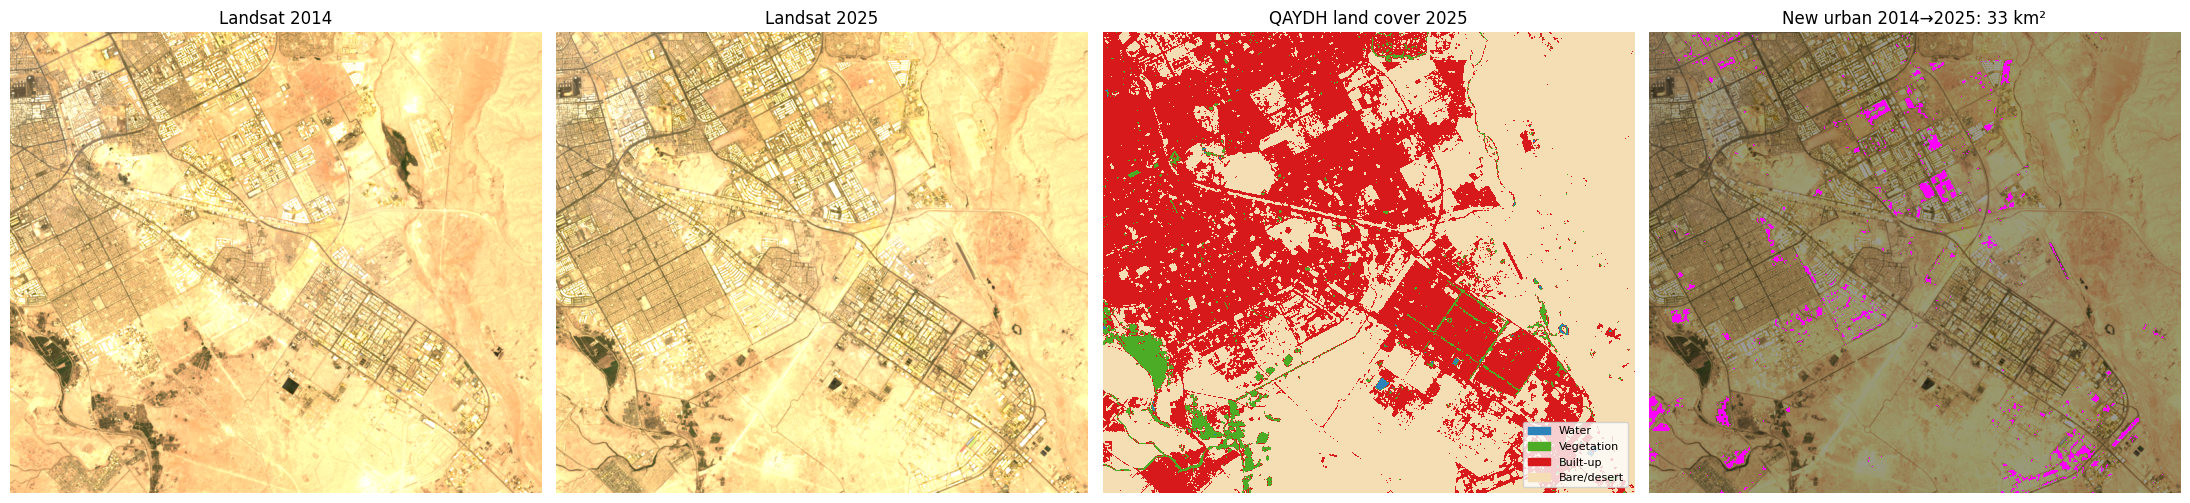

In [10]:
built0 = LC[YEAR_BEFORE] == BUILT; built1 = LC[YEAR_AFTER] == BUILT
NEW = new_urban(PB[YEAR_BEFORE], PB[YEAR_AFTER])
OLD = built0 & built1
px_km2 = 900 / 1e6
RESULTS.update(built_km2_before=float(built0.sum()*px_km2), built_km2_after=float(built1.sum()*px_km2),
               new_urban_km2=float(NEW.sum()*px_km2))
RESULTS["growth_pct"] = 100 * (RESULTS["built_km2_after"] / RESULTS["built_km2_before"] - 1)
print(f"Built-up {YEAR_BEFORE}: {RESULTS['built_km2_before']:.1f} km²  →  {YEAR_AFTER}: {RESULTS['built_km2_after']:.1f} km² "
      f"(+{RESULTS['growth_pct']:.0f}%) | confident new urban: {RESULTS['new_urban_km2']:.1f} km²")

def rgb(c, gain=3.0): return np.clip(np.dstack([c["red"], c["green"], c["blue"]]) * gain, 0, 1)
cmap4 = ListedColormap(["#2b83ba", "#4dac26", "#d7191c", "#f5deb3"])
fig, ax = plt.subplots(1, 4, figsize=(22, 6))
ax[0].imshow(rgb(comps[YEAR_BEFORE])); ax[0].set_title(f"Landsat {YEAR_BEFORE}")
ax[1].imshow(rgb(comps[YEAR_AFTER])); ax[1].set_title(f"Landsat {YEAR_AFTER}")
ax[2].imshow(np.ma.masked_less(LC[YEAR_AFTER], 0), cmap=cmap4, vmin=0, vmax=3); ax[2].set_title(f"QAYDH land cover {YEAR_AFTER}")
ax[2].legend(handles=[Patch(color=c, label=l) for c, l in zip(cmap4.colors, CLASSES)], loc="lower right", fontsize=8)
ax[3].imshow(rgb(comps[YEAR_AFTER]) * 0.6); ax[3].imshow(np.ma.masked_where(~NEW, NEW), cmap=ListedColormap(["#ff00ff"]))
ax[3].set_title(f"New urban {YEAR_BEFORE}→{YEAR_AFTER}: {RESULTS['new_urban_km2']:.0f} km²")
for a in ax: a.axis("off")
plt.tight_layout(); save_fig("01_urban_expansion"); plt.show()

## 5 · Layer 2 — Peak-summer heat hazard (Landsat surface temperature)

10 summer scenes | LST range (p2–p98): 48.0–56.1 °C


,zone,km2,mean_LST,ci_low,ci_high
0,Desert / bare,239.32,51.810001,51.65,51.97
1,Vegetation,15.94,50.439999,49.69,51.19
2,Established urban (built ≤2014),155.35,52.169998,51.97,52.38
3,New urban (2014–2025),32.60,51.869999,51.58,52.18


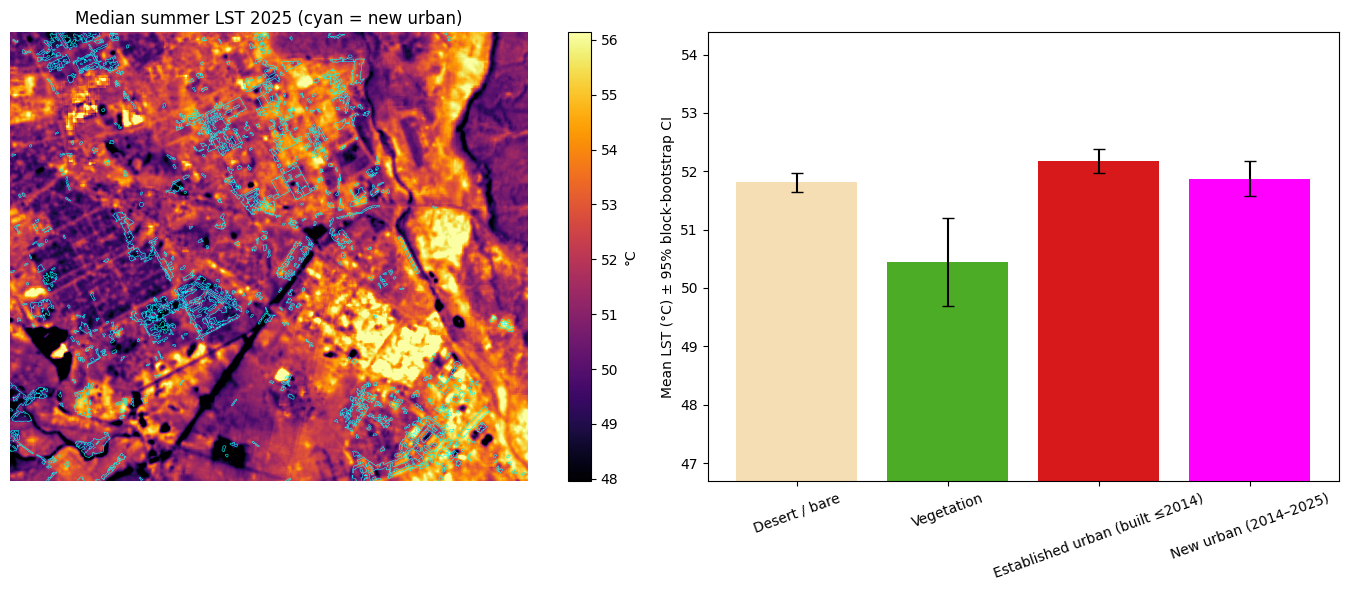

Reading tip: in Gulf deserts, open sand is often HOTTER than the city by day ('urban cool island'); the decision-relevant comparison is between districts where people live.


In [11]:
its = search_landsat(*LST_WINDOW)
ds = stac_load(its, ["lwir11", "qa_pixel"]); clear = ls_clear(ds["qa_pixel"].values)
lst_stack = lst_from_dn(ds["lwir11"].values); lst_stack[~clear] = np.nan
LST = np.nanmedian(lst_stack, 0)
PROV.append(dict(source="Landsat 8/9 C2 L2 surface temperature (ST_B10)", collection="landsat-c2-l2", items=[i.id for i in its],
                 dates=sorted(str(i.datetime.date()) for i in its), licence="Public domain (USGS)"))
print(f"{len(its)} summer scenes | LST range (p2–p98): {np.nanpercentile(LST,2):.1f}–{np.nanpercentile(LST,98):.1f} °C")

lc1 = LC[YEAR_AFTER]
groups_px = block_ids(SHAPE)
zones = {"Desert / bare": (lc1 == 3) & ~built1, "Vegetation": lc1 == 1,
         f"Established urban (built ≤{YEAR_BEFORE})": OLD, f"New urban ({YEAR_BEFORE}–{YEAR_AFTER})": NEW}
rng = np.random.default_rng(SEED); rows = []
for name, m in zones.items():
    m = m & np.isfinite(LST)
    if m.sum() < 50: continue
    g = groups_px[m]; v = LST[m]; agg_ = pd.DataFrame(dict(g=g, v=v)).groupby("g").v.agg(["sum", "count"])
    S_, N_ = agg_["sum"].values, agg_["count"].values   # resample whole ~1 km blocks, keep the pixel-weighted mean
    boots = [S_[j].sum() / N_[j].sum() for j in (rng.integers(0, len(S_), len(S_)) for _ in range(300))]
    rows.append(dict(zone=name, km2=m.sum()*px_km2, mean_LST=v.mean(), ci_low=np.percentile(boots, 2.5), ci_high=np.percentile(boots, 97.5)))
zone_lst = pd.DataFrame(rows).round(2); display(zone_lst)
RESULTS["lst_by_zone"] = zone_lst.to_dict("records")

fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw=dict(width_ratios=[1.3, 1]))
im = ax[0].imshow(LST, cmap="inferno", vmin=np.nanpercentile(LST, 2), vmax=np.nanpercentile(LST, 98))
ax[0].contour(NEW, levels=[0.5], colors="cyan", linewidths=0.4); ax[0].axis("off")
ax[0].set_title(f"Median summer LST {LST_WINDOW[0][:4]} (cyan = new urban)"); plt.colorbar(im, ax=ax[0], label="°C", fraction=0.04)
ax[1].bar(zone_lst.zone, zone_lst.mean_LST, yerr=[zone_lst.mean_LST-zone_lst.ci_low, zone_lst.ci_high-zone_lst.mean_LST],
          color=["#f5deb3", "#4dac26", "#d7191c", "#ff00ff"][:len(zone_lst)], capsize=4)
ax[1].set_ylabel("Mean LST (°C) ± 95% block-bootstrap CI"); ax[1].tick_params(axis="x", rotation=20)
ax[1].set_ylim(np.nanmin(zone_lst.ci_low) - 3, np.nanmax(zone_lst.ci_high) + 2)
plt.tight_layout(); save_fig("02_heat_hazard"); plt.show()
print("Reading tip: in Gulf deserts, open sand is often HOTTER than the city by day ('urban cool island');"
      " the decision-relevant comparison is between districts where people live.")

## 6 · Layer 3 — Hyperspectral surface materials (Planet Tanager)
Multispectral sensors see ~6 broad bands; Tanager's 426 narrow bands let us measure **physical drivers of heat** that Landsat cannot:
* **True broadband albedo**: reflectance integrated across 400–2450 nm and weighted by the solar spectrum.
* **Hydrocarbon Index (1705/1729/1741 nm, Kühn et al. 2004)**: asphalt and bitumen/plastic roofing, the darkest, hottest urban surfaces.
* **Al-OH (2200 nm) and carbonate (2330 nm) band depths**: clay and tile vs. concrete and limestone.
* **Red-edge (705/750 nm)**: the health of irrigated greenery, the main thing that cools a city.

Noisy water-vapour bands (1350–1450 and 1800–1950 nm) and the >2450 nm detector edge are removed, as in the official notebook.

In [12]:
sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in tan_item["assets"] else "basic_sr_hdf5"
h5_url = tan_item["assets"][sr_key]["href"]; H5 = os.path.join(DATA, os.path.basename(h5_url.split("?")[0]))
download(h5_url, H5, "Tanager SR cube (~0.9 GB, several minutes)")
bands_meta = [b for b in tan_item["assets"][sr_key].get("bands", [])
              if "eo:center_wavelength" in b and b.get("name", "surface_reflectance").startswith("surface_reflectance")
              and "uncertainty" not in b.get("name", "")]
WL = np.array([b["eo:center_wavelength"] for b in bands_meta], float) * 1000.0
ROOT = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(H5, "r") as f:
    srd = f[f"{ROOT}/surface_reflectance"]; NB, TH, TW = srd.shape
    beta_cloud = f[f"{ROOT}/beta_cloud_mask"][:]
    nodata = f[f"{ROOT}/nodata_pixels"][:] if f"{ROOT}/nodata_pixels" in f else np.zeros((TH, TW), np.uint8)
print(f"Cube: {NB} bands × {TH} × {TW} px | wavelengths {WL.min():.0f}–{WL.max():.0f} nm")

good = np.array([i for i, w in enumerate(WL) if not is_bad_band(w)])
targets = [470, 560, 670, 705, 750, 800, 860, 1380, 1610, 1705, 1729, 1741, 2120, 2200, 2250, 2270, 2330, 2390]
need = {int(np.argmin(abs(WL - t))) for t in targets}
stride = 4
while (len(good[::stride]) + len(need)) * TH * TW * 4 > 2.0e9: stride += 1   # keep RAM < ~2 GB
SEL = np.array(sorted(set(good[::stride]) | need)); WLS = WL[SEL]
with h5py.File(H5, "r") as f:
    CUBE = f[f"{ROOT}/surface_reflectance"][list(SEL), :, :].astype("float32")
CUBE[CUBE < 0] = np.nan
R = lambda t: CUBE[int(np.argmin(abs(WLS - t)))]
if np.nanmedian(R(860)) > 1.5: CUBE /= 10000.0; print("rescaled reflectance /10000")
DATAOK = (nodata == 0) & np.isfinite(R(860)) & (R(860) > 0)
# Planet's *beta* cloud mask flags bright desert sand and concrete as cloud over Gulf cities.
# We compare it with a physics-based test and keep whichever is plausible, and we report both numbers.
own_cloud = tanager_cloud_test(R) & DATAOK
beta_frac, own_frac = (beta_cloud.astype(bool) & DATAOK).sum() / DATAOK.sum(), own_cloud.sum() / DATAOK.sum()
use_beta = beta_frac < 2 * own_frac + 0.10
cloud = (beta_cloud.astype(bool) if use_beta else own_cloud)
TVALID = DATAOK & ~cloud
print(f"Cloud: Planet beta mask flags {beta_frac*100:.1f}% | physics test flags {own_frac*100:.1f}% → using "
      f"{'beta mask' if use_beta else 'physics test (beta mask = bright-surface false positives)'}")
RESULTS.update(tanager_beta_cloud_pct=float(beta_frac*100), tanager_physics_cloud_pct=float(own_frac*100), tanager_cloud_mask_used="beta" if use_beta else "physics")
print(f"Read {len(SEL)} bands (stride {stride}) | valid pixels {TVALID.mean()*100:.1f}% of grid")

Cube: 426 bands × 654 × 760 px | wavelengths 376–2499 nm


Cloud: Planet beta mask flags 74.1% | physics test flags 0.0% → using physics test (beta mask = bright-surface false positives)
Read 100 bands (stride 4) | valid pixels 72.9% of grid


In [13]:
# --- physically-based hyperspectral features ---
# keep a band only if it is outside the absorption windows AND valid on >98% of clear pixels (drops e.g. the 1952 nm edge band)
gsel = np.array([(not is_bad_band(w)) and np.isfinite(CUBE[b][TVALID]).mean() > 0.98 for b, w in enumerate(WLS)])
print(f"{gsel.sum()} of {len(WLS)} loaded bands kept for spectral analysis")
# physically impossible reflectance (>1.0 in any kept band = saturation / glint artefact) -> invalid
sat = np.zeros((TH, TW), bool)
for b in np.flatnonzero(gsel): sat |= CUBE[b] > 1.0
TVALID &= ~sat; RESULTS["tanager_saturated_pct"] = float(sat.mean() * 100)
print(f"Masked {sat.mean()*100:.2f}% saturated pixels (reflectance > 1)")
w_sun = planck(WLS) * np.gradient(WLS); w_sun[~gsel] = 0; w_sun /= w_sun.sum()
HS = {}
HS["albedo_hs"] = np.zeros((TH, TW), "float32")
for b in np.flatnonzero(gsel): HS["albedo_hs"] += w_sun[b] * np.nan_to_num(CUBE[b])
HS["ndvi_hs"]   = nd(R(860), R(670))
HS["ndre"]      = nd(R(750), R(705))
HS["hi"]        = hydrocarbon_index(R, WLS)
HS["bd2200"]    = band_depth(R, WLS, 2120, 2200, 2250)
HS["bd2330"]    = band_depth(R, WLS, 2270, 2330, 2390)
for k in HS: HS[k] = np.where(TVALID, HS[k], np.nan).astype("float32")

# --- unsupervised spectral material clusters (PCA -> k-means) ---
CUBE2 = CUBE.reshape(len(SEL), -1)                                # bands x pixels (view, no copy)
def getspec(j): return CUBE2[:, j][gsel].T                        # pixels x good bands
fin = TVALID.copy()
for b in np.flatnonzero(gsel): fin &= np.isfinite(CUBE[b])
vidx = np.flatnonzero(fin.ravel())
rng = np.random.default_rng(SEED); fit_idx = rng.choice(vidx, min(80_000, len(vidx)), replace=False)
S_fit = getspec(fit_idx); pca = PCA(6, random_state=SEED).fit(S_fit)
km = MiniBatchKMeans(8, random_state=SEED, n_init=5, batch_size=4096).fit(pca.transform(S_fit))
CL = np.full(TH * TW, -1, np.int16); PCS = np.full((TH * TW, 4), np.nan, "float32")
for s in range(0, len(vidx), 300_000):
    j = vidx[s:s + 300_000]; z = pca.transform(getspec(j)); CL[j] = km.predict(z); PCS[j] = z[:, :4]
CL = CL.reshape(TH, TW)
for k in range(4): HS[f"pc{k+1}"] = PCS[:, k].reshape(TH, TW)
print("PCA explained variance:", np.round(pca.explained_variance_ratio_, 3))

rows = []
for k in range(8):
    m = CL == k
    rows.append(dict(cluster=k, share=m.mean() / TVALID.mean(), albedo=np.nanmean(HS["albedo_hs"][m]), ndvi=np.nanmean(HS["ndvi_hs"][m]),
                     hi=np.nanmean(HS["hi"][m]), bd2200=np.nanmean(HS["bd2200"][m]), bd2330=np.nanmean(HS["bd2330"][m])))
mat = pd.DataFrame(rows)
# names are relative to this city (Gulf cities are bright: absolute thresholds from temperate cities do not transfer)
a_rank = mat.albedo.rank(); c_rank = mat.bd2330.rank(); hi_med = mat.hi.median()
def name_cluster(r):
    if r.ndvi > 0.35: return "Vegetation (irrigated / trees)"
    if r.ndvi > 0.12: return "Sparse / irrigated greenery & gardens"
    if a_rank[r.name] <= 2: return "Darkest impervious: asphalt roads / dark roofs" if r.hi > hi_med else "Darkest urban fabric: shaded / dense blocks"
    if a_rank[r.name] >= 7: return "Brightest: high-albedo roofs / pale sand"
    if c_rank[r.name] >= 7: return "Carbonate-rich: concrete / limestone ground"
    return "Mixed urban fabric / bare soil"
mat["suggested_material"] = mat.apply(name_cluster, axis=1)
display(mat.round(3)); RESULTS["materials"] = mat.round(4).to_dict("records")
DARK_T = float(np.nanpercentile(HS["albedo_hs"][TVALID & (HS["ndvi_hs"] < 0.25)], 20))   # darkest 20% of non-green surfaces
print(f"Dark-surface threshold for this city: albedo < {DARK_T:.3f}"); RESULTS["dark_albedo_threshold"] = DARK_T
dark = (HS["albedo_hs"] < DARK_T) & (HS["ndvi_hs"] < 0.25) & (HS["albedo_hs"] > 0.03)
HS["dark_frac"] = np.where(TVALID, dark, np.nan).astype("float32")
HS["asphalt_frac"] = np.where(TVALID, dark & (HS["hi"] > 0), np.nan).astype("float32")

98 of 100 loaded bands kept for spectral analysis
Masked 0.12% saturated pixels (reflectance > 1)


PCA explained variance: [0.885 0.08  0.024 0.006 0.002 0.001]


,cluster,share,albedo,ndvi,hi,bd2200,bd2330,suggested_material
0,0,0.042,0.454,-0.019,0.003,-0.034,-0.021,Brightest: high-albedo roofs / pale sand
1,1,0.180,0.339,0.031,0.002,-0.014,0.030,Mixed urban fabric / bare soil
2,2,0.194,0.421,0.048,0.002,0.007,0.074,Carbonate-rich: concrete / limestone ground
3,3,0.103,0.297,0.031,0.003,-0.015,0.024,Darkest impervious: asphalt roads / dark roofs
4,4,0.152,0.370,0.023,0.002,-0.011,0.029,Mixed urban fabric / bare soil
5,5,0.157,0.453,0.048,0.002,0.009,0.089,Brightest: high-albedo roofs / pale sand
6,6,0.150,0.395,0.038,0.002,-0.001,0.052,Mixed urban fabric / bare soil
7,7,0.022,0.258,0.174,0.003,-0.026,0.018,Sparse / irrigated greenery & gardens


Dark-surface threshold for this city: albedo < 0.337


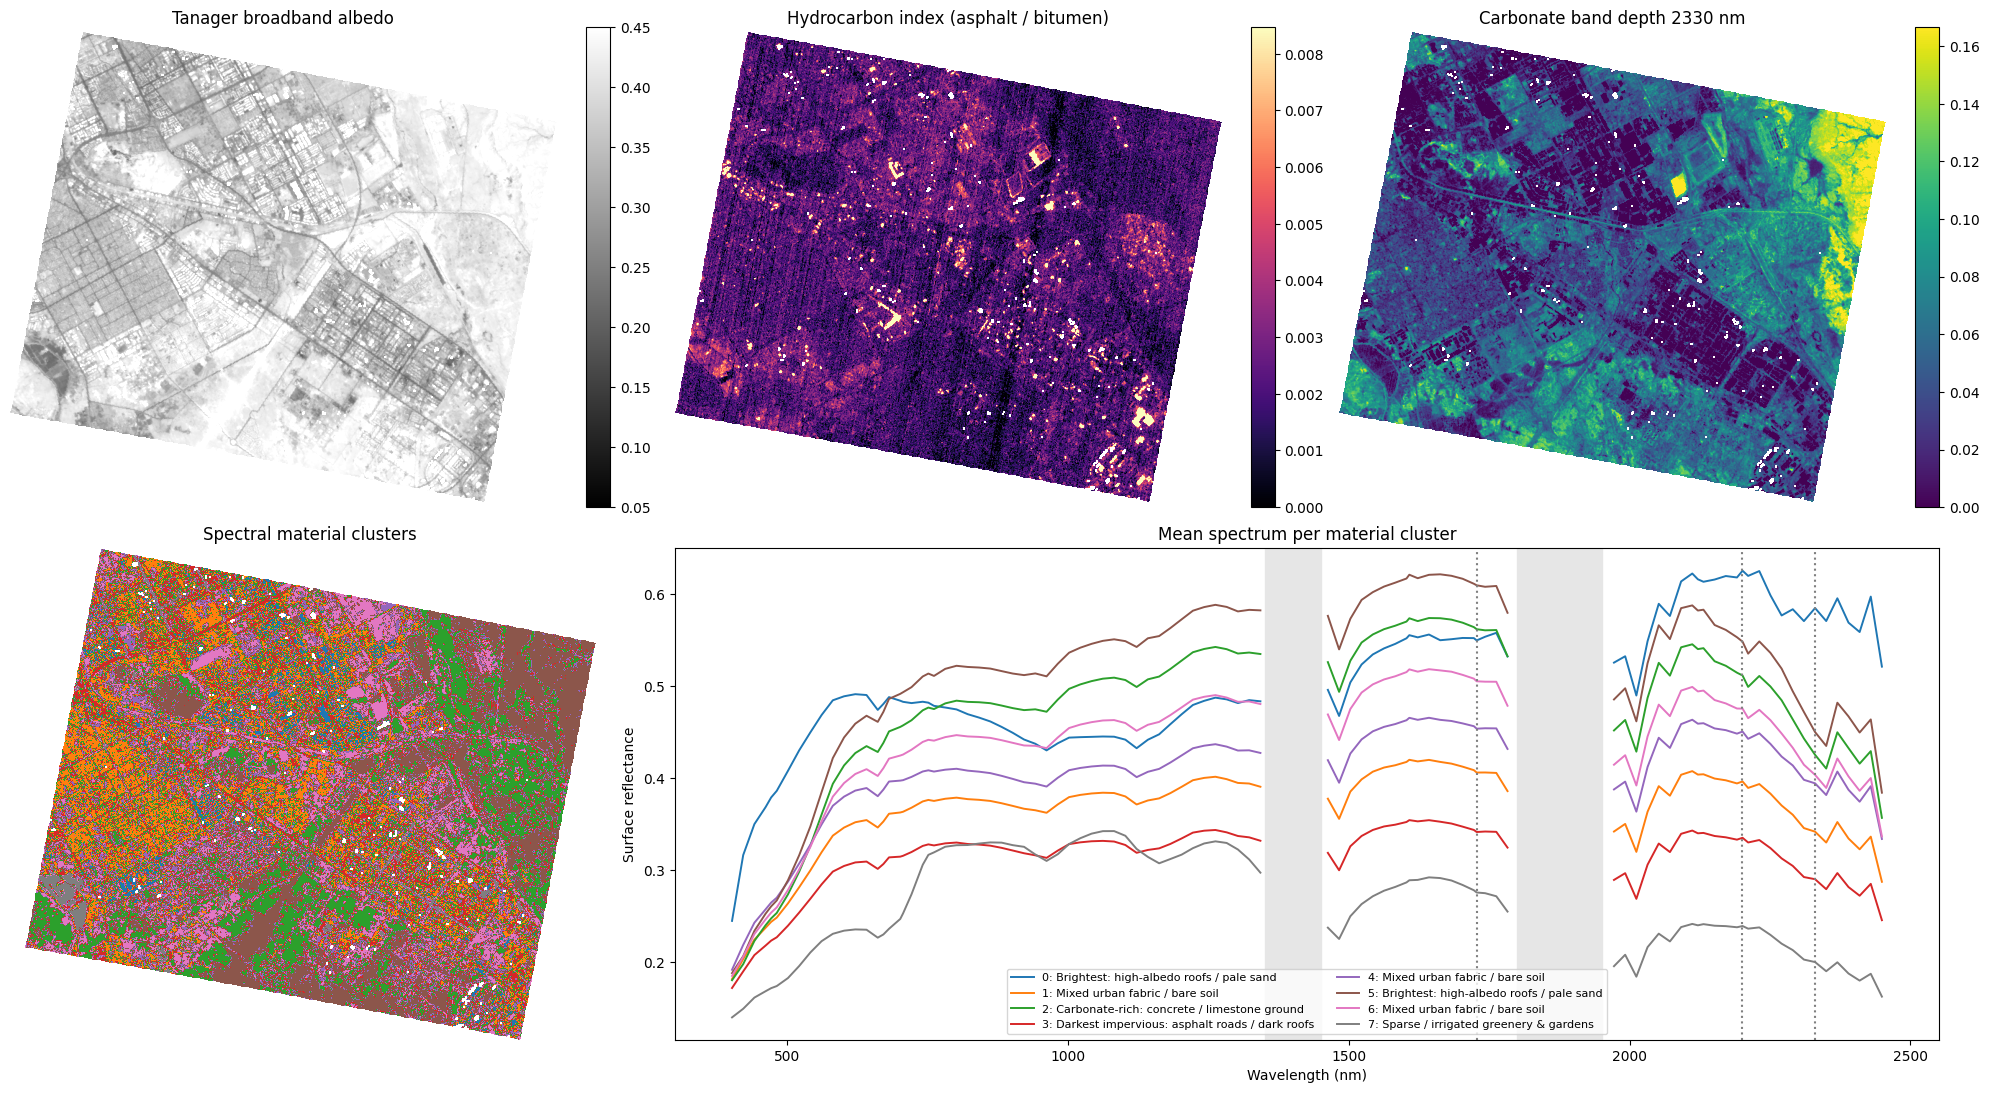

In [14]:
fig = plt.figure(figsize=(20, 11)); gsp = fig.add_gridspec(2, 3)
def show(ax, a, t, cmap, vmin=None, vmax=None):
    im = ax.imshow(a, cmap=cmap, vmin=vmin, vmax=vmax); ax.set_title(t); ax.axis("off"); plt.colorbar(im, ax=ax, fraction=0.04)
show(fig.add_subplot(gsp[0, 0]), HS["albedo_hs"], "Tanager broadband albedo", "gray", 0.05, 0.45)
show(fig.add_subplot(gsp[0, 1]), HS["hi"], "Hydrocarbon index (asphalt / bitumen)", "magma", 0, np.nanpercentile(HS["hi"], 99))
show(fig.add_subplot(gsp[0, 2]), HS["bd2330"], "Carbonate band depth 2330 nm", "viridis", 0, np.nanpercentile(HS["bd2330"], 99))
pal = plt.get_cmap("tab10").colors[:8]
ax = fig.add_subplot(gsp[1, 0]); ax.imshow(np.ma.masked_less(CL, 0), cmap=ListedColormap(pal), vmin=0, vmax=7); ax.axis("off")
ax.set_title("Spectral material clusters")
ax = fig.add_subplot(gsp[1, 1:])
for k in range(8):
    j = np.flatnonzero(CL.ravel() == k)
    if len(j) == 0: continue
    s = np.nanmean(getspec(np.random.default_rng(k).choice(j, min(5000, len(j)), replace=False)), 0)
    y = np.full(len(WLS), np.nan); y[gsel] = s
    ax.plot(WLS, y, color=pal[k], lw=1.4, label=f"{k}: {mat.suggested_material[k]}")
for lo, hi_ in [(1350, 1450), (1800, 1950)]: ax.axvspan(lo, hi_, color="0.9")
for w_ in [1729, 2200, 2330]: ax.axvline(w_, ls=":", c="0.5")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Surface reflectance"); ax.legend(fontsize=8, ncol=2); ax.set_title("Mean spectrum per material cluster")
plt.tight_layout(); save_fig("03_hyperspectral_materials"); plt.show()

### 6b · Put Tanager on the Landsat grid + automatic co-registration check

Tanager georeference: HDF-EOS StructMetadata (UTM) EPSG:32638
Tanager vs Landsat albedo  r = 0.849 (as georeferenced) → 0.871 after shift dy=1, dx=1 px


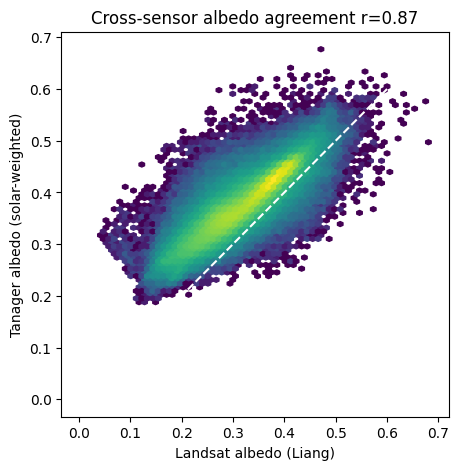

In [15]:
T_CRS, T_TR, how = tanager_georef(H5, tan_item, sr_key, (TH, TW)); print("Tanager georeference:", how, T_CRS)
HSG = {k: to_grid(v, T_CRS, T_TR, SHAPE, TR, CRS_DST) for k, v in HS.items()}
ls_alb = FEAT[YEAR_AFTER]["albedo"]
r0 = corr(HSG["albedo_hs"], ls_alb); rbest, dy, dx = best_shift(HSG["albedo_hs"], ls_alb, r=4)
print(f"Tanager vs Landsat albedo  r = {r0:.3f} (as georeferenced) → {rbest:.3f} after shift dy={dy}, dx={dx} px")
if (dy, dx) != (0, 0): HSG = {k: shift2d(v, dy, dx) for k, v in HSG.items()}
RESULTS.update(coreg_r_before=r0, coreg_r_after=rbest, coreg_shift_px=[dy, dx], georef_method=how)
if rbest < 0.5: print("⚠️ low agreement — check georeferencing before trusting Tanager-derived results")
ok = np.isfinite(HSG["albedo_hs"]) & np.isfinite(ls_alb)
plt.figure(figsize=(5, 5)); plt.hexbin(ls_alb[ok], HSG["albedo_hs"][ok], gridsize=60, bins="log", cmap="viridis")
plt.plot([0, .6], [0, .6], "w--"); plt.xlabel("Landsat albedo (Liang)"); plt.ylabel("Tanager albedo (solar-weighted)")
plt.title(f"Cross-sensor albedo agreement r={rbest:.2f}"); save_fig("04_albedo_agreement"); plt.show()

## 7 · Does hyperspectral add value? (the key test)
We predict summer LST from (A) Landsat features only, and (B) Landsat **plus** Tanager material features, using a Random Forest scored with **spatial-block cross-validation**. A real gain in R² means hyperspectral explains heat that multispectral misses, and the gain is reported honestly whichever way it comes out.

,subset,features,R2,R2_sd,RMSE_C
0,All pixels in Tanager footprint,A: Landsat only,0.441,0.032,1.475
1,All pixels in Tanager footprint,B: Landsat + Tanager,0.528,0.033,1.357
2,Built-up pixels only,A: Landsat only,0.310,0.030,1.593
3,Built-up pixels only,B: Landsat + Tanager,0.441,0.022,1.435


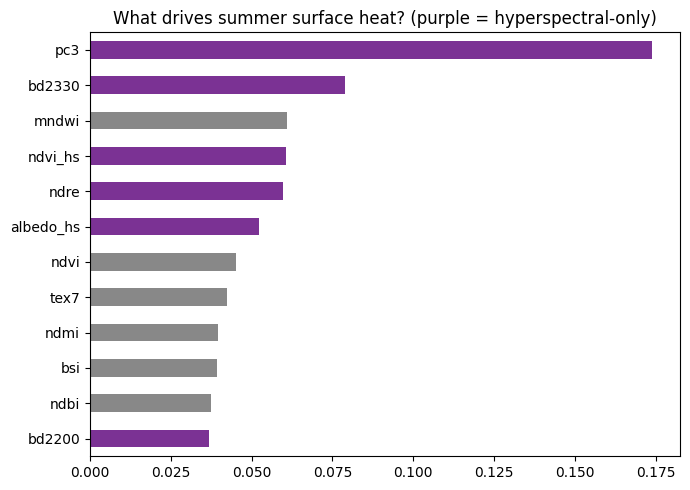

In [16]:
HS_FEATS = ["albedo_hs", "ndvi_hs", "ndre", "hi", "bd2200", "bd2330", "pc1", "pc2", "pc3", "pc4", "dark_frac"]
FA = FEAT[YEAR_AFTER]; XA = stack(FA, FEATS_LS); XB = np.concatenate([XA, stack(HSG, HS_FEATS)], -1)
valid_px = np.isfinite(XB).all(-1) & np.isfinite(LST)
rows = []
for subset, m in [("All pixels in Tanager footprint", valid_px), ("Built-up pixels only", valid_px & built1)]:
    ii = np.flatnonzero(m.ravel())
    if len(ii) < 2000: continue
    ii = np.random.default_rng(SEED).choice(ii, min(20_000, len(ii)), replace=False)
    y = LST.ravel()[ii]; g = groups_px.ravel()[ii]
    for name, X in [("A: Landsat only", XA), ("B: Landsat + Tanager", XB)]:
        r2m, r2s, rm = cv_regress(X.reshape(-1, X.shape[-1])[ii], y, g)
        rows.append(dict(subset=subset, features=name, R2=r2m, R2_sd=r2s, RMSE_C=rm))
val = pd.DataFrame(rows).round(3); display(val)
for s in val.subset.unique():
    v = val[val.subset == s].set_index("features")
    RESULTS[f"dR2_{'built' if 'Built' in s else 'all'}"] = float(v.loc["B: Landsat + Tanager", "R2"] - v.loc["A: Landsat only", "R2"])
RESULTS["lst_model"] = val.to_dict("records")

ii = np.flatnonzero(valid_px.ravel()); ii = np.random.default_rng(SEED).choice(ii, min(40_000, len(ii)), replace=False)
mB = RandomForestRegressor(150, min_samples_leaf=5, max_features=0.4, n_jobs=-1, random_state=SEED).fit(XB.reshape(-1, XB.shape[-1])[ii], LST.ravel()[ii])
imp = pd.Series(mB.feature_importances_, FEATS_LS + HS_FEATS).sort_values()[-12:]
plt.figure(figsize=(7, 5)); imp.plot.barh(color=["#7b3294" if n in HS_FEATS else "#888" for n in imp.index])
plt.title("What drives summer surface heat? (purple = hyperspectral-only)"); plt.tight_layout(); save_fig("05_heat_drivers"); plt.show()

## 7b · Layer 4 — People exposure: who is outside in this heat?
Heat risk is about **people**, not pixels. A hot warehouse roof matters less than a hot bus stop. We add two open layers:
* **WorldPop 2025 constrained population (100 m, CC-BY-4.0)**: how many people live in each 300 m cell.
* **OpenStreetMap (ODbL)**: places where people are *outdoors* in the heat:
  * 🕌 **mosques**: walking to Dhuhr and Asr prayers, at peak heat
  * 🚌 **bus stops**: waiting unshaded
  * 🛵 **delivery-rider hubs**: restaurants, cafés and shops, where motorbike riders wait and pick up
  * 🏗️ **construction sites**: outdoor workers
  * 🏫 **schools and clinics**: vulnerable groups (children, patients)
  * 🌳 **parks**: potential cooling refuges

Exposure per cell = 0.6 × population rank + 0.4 × outdoor-activity rank (within ~450 m walking distance).

Population in AOI: 1,091,324


,OSM places in AOI
cat,
mosque,171
park,113
bus_stop,59
vulnerable,43
delivery,37
construction,11


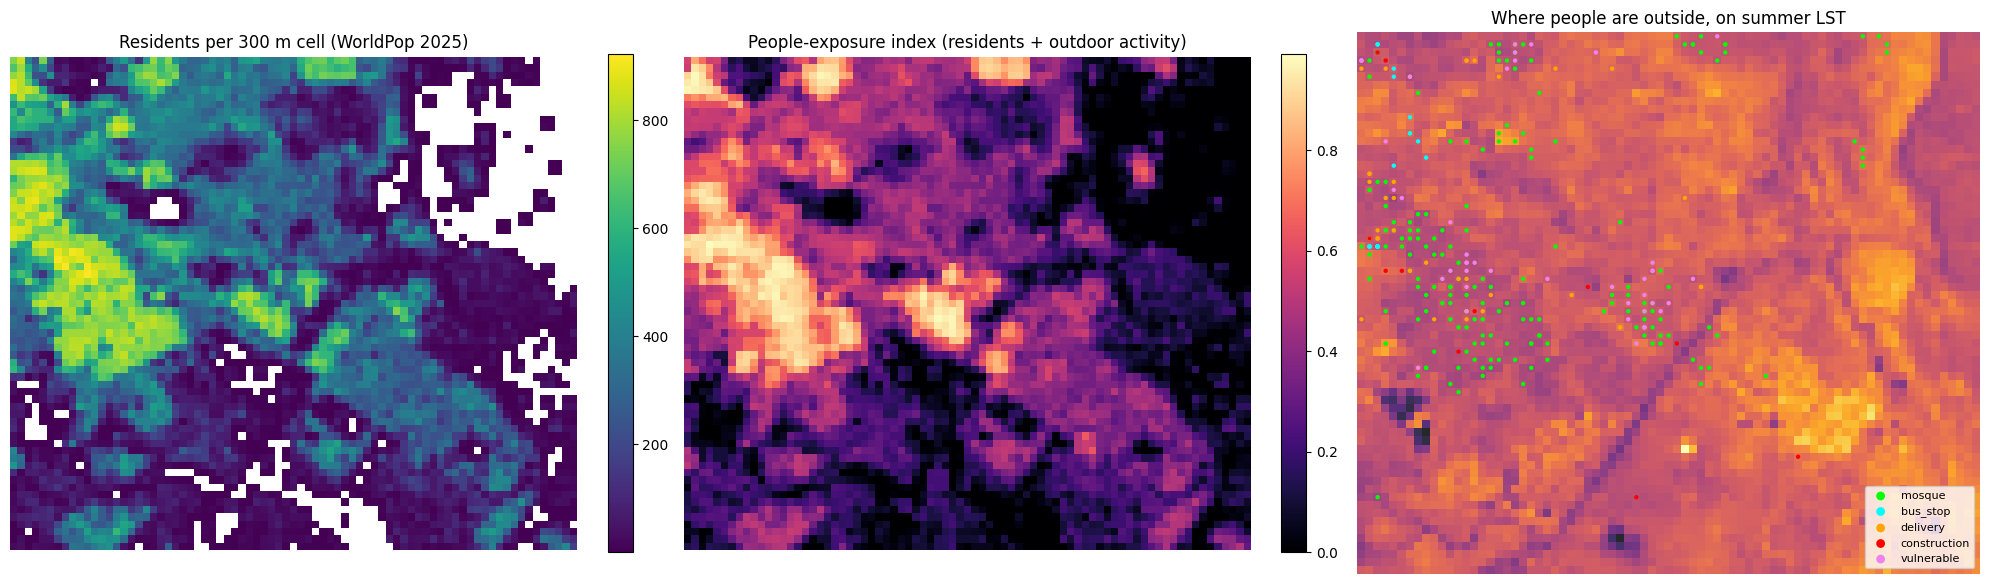

,places,pct_in_hottest_20pct,mean_LST_C
mosque,171,4.7,50.9
bus_stop,59,0.0,50.7
delivery,37,5.4,51.2
construction,11,0.0,51.4
vulnerable,43,2.3,50.9
park,112,1.8,51.2


Mapped amenities per 10,000 residents (157,076 residents live in the hottest 20% of populated cells):


,hottest_20pct,rest_of_city
mosque,0.51,1.74
bus_stop,0.00,0.63
delivery,0.13,0.37
vulnerable,0.06,0.45
park,0.13,1.18


Residents living in the hottest 10% of populated cells: 80,469


In [17]:
import rasterio.windows
from rasterio.warp import transform_bounds
GRID_BOUNDS = (TR.c, TR.f + TR.e * SHAPE[0], TR.c + TR.a * SHAPE[1], TR.f)
CELL_SHAPE = (SHAPE[0] // CELL_PX, SHAPE[1] // CELL_PX); CELL_TR = TR * Affine.scale(CELL_PX)

# --- population (WorldPop 2025, constrained, 100 m) ---
WP_URL = (f"https://data.worldpop.org/GIS/Population/Global_2015_2030/R2025A/2025/{COUNTRY_ISO3}/v1/100m/constrained/"
          f"{COUNTRY_ISO3.lower()}_pop_2025_CN_100m_R2025A_v1.tif")
wp_path = download(WP_URL, os.path.join(DATA, os.path.basename(WP_URL)), "WorldPop 2025 population")
with rasterio.open(wp_path) as src:
    win = rasterio.windows.from_bounds(*transform_bounds(CRS_DST, src.crs, *GRID_BOUNDS, densify_pts=21), src.transform).round_offsets().round_lengths()
    wp = src.read(1, window=win, boundless=True, fill_value=0).astype("float32"); wp[wp < 0] = 0
    POP_C = np.zeros(CELL_SHAPE, "float32")
    reproject(wp, POP_C, src_transform=src.window_transform(win), src_crs=src.crs, dst_transform=CELL_TR, dst_crs=CRS_DST,
              resampling=Resampling.sum, src_nodata=None)
PROV.append(dict(source="WorldPop 2025 constrained population 100 m (R2025A)", collection=WP_URL, items=[os.path.basename(WP_URL)], dates=["2025"], licence="CC-BY-4.0 © WorldPop"))
print(f"Population in AOI: {POP_C.sum():,.0f}")

# --- OpenStreetMap places where people are outdoors ---
OSM_CATS = {
    "mosque":       ['nwr["amenity"="place_of_worship"]'],
    "bus_stop":     ['node["highway"="bus_stop"]', 'nwr["public_transport"="platform"]["bus"="yes"]'],
    "delivery":     ['nwr["amenity"~"^(restaurant|fast_food|cafe|food_court)$"]', 'nwr["shop"~"^(supermarket|convenience|bakery|mall)$"]'],
    "construction": ['nwr["landuse"="construction"]', 'nwr["building"="construction"]'],
    "vulnerable":   ['nwr["amenity"~"^(school|kindergarten|clinic|hospital|doctors)$"]'],
    "park":         ['nwr["leisure"~"^(park|garden|playground)$"]'],
}
POI_KEYS = ["mosque", "bus_stop", "delivery", "construction", "vulnerable", "park"]
osm_path = os.path.join(DATA, f"osm_pois_{TANAGER_ID}.json")
if not os.path.exists(osm_path):
    s, w_, n, e = AOI[1], AOI[0], AOI[3], AOI[2]
    q = "[out:json][timeout:120];(" + "".join(f"{x}({s},{w_},{n},{e});" for v in OSM_CATS.values() for x in v) + ");out tags center;"
    for ep in ["https://overpass-api.de/api/interpreter", "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
               "https://overpass.kumi.systems/api/interpreter"]:
        try:
            r = requests.post(ep, data={"data": q}, timeout=180, headers={"User-Agent": f"QAYDH-{TEAM}-hackathon/1.0"})
            r.raise_for_status(); osm = r.json(); json.dump(osm, open(osm_path, "w")); print("OSM via", ep); break
        except Exception as ex: print("  Overpass endpoint failed:", ep, type(ex).__name__)
osm = json.load(open(osm_path))
def osm_cat(t):
    if t.get("amenity") == "place_of_worship": return "mosque" if t.get("religion", "muslim") == "muslim" else None
    if t.get("highway") == "bus_stop" or t.get("public_transport") == "platform": return "bus_stop"
    if t.get("landuse") == "construction" or t.get("building") == "construction": return "construction"
    if t.get("amenity") in ("school", "kindergarten", "clinic", "hospital", "doctors"): return "vulnerable"
    if t.get("leisure") in ("park", "garden", "playground"): return "park"
    if t.get("amenity") in ("restaurant", "fast_food", "cafe", "food_court") or t.get("shop"): return "delivery"
rows = []
for el in osm["elements"]:
    t = el.get("tags", {}); lat = el.get("lat", el.get("center", {}).get("lat")); lon = el.get("lon", el.get("center", {}).get("lon"))
    c = osm_cat(t)
    if c and lat is not None: rows.append(dict(cat=c, lat=lat, lon=lon, name=t.get("name:en") or t.get("name") or ""))
POIS = pd.DataFrame(rows, columns=["cat", "lat", "lon", "name"])
PROV.append(dict(source="OpenStreetMap via Overpass API", collection="OSM", items=[f"{len(POIS)} POIs"], dates=[osm.get("osm3s", {}).get("timestamp_osm_base", "")], licence="ODbL © OpenStreetMap contributors"))
display(POIS.cat.value_counts().rename("OSM places in AOI").to_frame())

# rasterise POI counts onto the 300 m decision cells
to_utm = __import__("pyproj").Transformer.from_crs("EPSG:4326", CRS_DST, always_xy=True)
x, y = to_utm.transform(POIS.lon.values, POIS.lat.values)
cols, rows_ = ~CELL_TR * (np.asarray(x), np.asarray(y)); cols = np.floor(cols).astype(int); rows_ = np.floor(rows_).astype(int)
POIS["r"], POIS["c"] = rows_, cols
inside = (rows_ >= 0) & (rows_ < CELL_SHAPE[0]) & (cols >= 0) & (cols < CELL_SHAPE[1])
CX = {"pop": POP_C}
for k in POI_KEYS:
    a = np.zeros(CELL_SHAPE, "float32"); m = inside & (POIS.cat.values == k)
    np.add.at(a, (rows_[m], cols[m]), 1); CX[k] = a

# outdoor-activity score: weighted places within ~450 m (3x3 cells)
OUT_W = dict(mosque=1.0, bus_stop=1.0, delivery=0.5, construction=2.0, vulnerable=1.0)
outdoor = sum(w * uniform_filter(CX[k], 3, mode="constant") * 9 for k, w in OUT_W.items())
lived = np.isfinite(aggregate(LST))
pr = lambda a: np.nan_to_num(pct_rank(a, lived & (a > 0)))      # rank among cells that have any people/activity
CX["outdoor"] = outdoor
CX["expo"] = 0.6 * pr(POP_C) + 0.4 * pr(outdoor)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
im = ax[0].imshow(np.ma.masked_less_equal(POP_C, 0), cmap="viridis"); ax[0].set_title("Residents per 300 m cell (WorldPop 2025)"); plt.colorbar(im, ax=ax[0], fraction=0.04)
im = ax[1].imshow(CX["expo"], cmap="magma"); ax[1].set_title("People-exposure index (residents + outdoor activity)"); plt.colorbar(im, ax=ax[1], fraction=0.04)
ax[2].imshow(aggregate(LST), cmap="inferno", alpha=0.85)
for k, col in [("mosque", "lime"), ("bus_stop", "cyan"), ("delivery", "orange"), ("construction", "red"), ("vulnerable", "violet")]:
    s_ = POIS[(POIS.cat == k) & inside]; ax[2].scatter(s_.c, s_.r, s=10, c=col, label=k, edgecolors="none")
ax[2].legend(loc="lower right", fontsize=8, markerscale=2); ax[2].set_title("Where people are outside, on summer LST")
for a in ax: a.axis("off")
plt.tight_layout(); save_fig("07_people_exposure"); plt.show()

# who is exposed? share of each group's places that sit in the hottest 20% of populated cells
lst_c = aggregate(LST); hot20 = lst_c >= np.nanpercentile(lst_c[lived & (CX["expo"] > 0)], 80)
share = {}
for k in ["mosque", "bus_stop", "delivery", "construction", "vulnerable", "park"]:
    s_ = POIS[(POIS.cat == k) & inside]
    if len(s_) >= 3: share[k] = 100 * hot20[s_.r, s_.c].mean()
mean_lst_at = {k: float(np.nanmean(lst_c[POIS[(POIS.cat == k) & inside].r, POIS[(POIS.cat == k) & inside].c])) for k in share}
expo_tab = pd.DataFrame(dict(places=[int(((POIS.cat == k) & inside).sum()) for k in share], pct_in_hottest_20pct=share.values(),
                             mean_LST_C=mean_lst_at.values()), index=share.keys()).round(1)
display(expo_tab)
RESULTS["poi_share_in_hot20"] = share; RESULTS["mean_lst_at_poi"] = mean_lst_at
# service gap: outdoor amenities per 10,000 residents in the hottest 20% of populated cells vs the rest
popm = lived & (POP_C > 0); hotp, coolp = hot20 & popm, ~hot20 & popm
gap = pd.DataFrame({k: dict(hottest_20pct=1e4 * CX[k][hotp].sum() / max(POP_C[hotp].sum(), 1),
                            rest_of_city=1e4 * CX[k][coolp].sum() / max(POP_C[coolp].sum(), 1))
                    for k in ["mosque", "bus_stop", "delivery", "vulnerable", "park"]}).T.round(2)
print(f"Mapped amenities per 10,000 residents ({POP_C[hotp].sum():,.0f} residents live in the hottest 20% of populated cells):")
display(gap); RESULTS["amenities_per_10k_hot_vs_rest"] = gap.to_dict("index"); RESULTS["residents_hot20"] = float(POP_C[hotp].sum())
RESULTS["people_in_top_decile_cells"] = float(POP_C[lst_c >= np.nanpercentile(lst_c[lived & (POP_C > 0)], 90)].sum())
RESULTS["population_aoi"] = float(POP_C.sum())
print(f"Residents living in the hottest 10% of populated cells: {RESULTS['people_in_top_decile_cells']:,.0f}")


## 8 · Layer 5 — Heat-Risk Priority Index (300 m decision cells, people-aware) + cool-roof what-if

In [18]:
# interpretable cooling slope inside the city: LST ~ albedo + NDVI (block-bootstrap 95% CI)
m = built1 & np.isfinite(LST) & np.isfinite(FA["albedo"]) & np.isfinite(FA["ndvi"])
ii = np.flatnonzero(m.ravel()); ii = np.random.default_rng(SEED).choice(ii, min(60_000, len(ii)), replace=False)
beta, lo, hi_ = block_bootstrap_ols(np.c_[FA["albedo"].ravel()[ii], FA["ndvi"].ravel()[ii]], LST.ravel()[ii], groups_px.ravel()[ii])
slope, slo, shi = beta[1] * 0.1, lo[1] * 0.1, hi_[1] * 0.1
gslope = beta[2] * 0.1
print(f"Inside built-up areas: +0.10 albedo ⇒ {slope:+.2f} °C LST (95% CI {slo:+.2f} to {shi:+.2f}); +0.10 NDVI ⇒ {gslope:+.2f} °C")
RESULTS.update(cooling_per_0p1_albedo_C=[slope, slo, shi], cooling_per_0p1_ndvi_C=gslope)

f = CELL_PX
C = dict(lst=aggregate(LST), built_frac=aggregate(built1.astype("float32")), green_frac=aggregate((FA["ndvi"] > 0.3).astype("float32")),
         new_frac=aggregate(NEW.astype("float32")), dark_frac=aggregate(HSG["dark_frac"]), asphalt_frac=aggregate(HSG["asphalt_frac"]))
C.update({k: v for k, v in CX.items()})      # people-exposure layers from section 7b
# people-aware index (submission) and the buildings-only index (what a planner would get without people data)
SCORE, URB = hrpi(C["lst"], C["expo"], C["green_frac"], C["new_frac"], built_c=C["built_frac"])
SCORE_BLD, _ = hrpi(C["lst"], C["built_frac"], C["green_frac"], C["new_frac"], built_c=C["built_frac"])

# weight sensitivity: overlap of top-20 cells under alternative weightings
def topk(s, k=20): return set(np.argsort(np.nan_to_num(s, nan=-1).ravel())[-k:])
base = topk(SCORE); sens = {}
for name, w in {"hazard×exposure only": (1, .5, 0, 0), "green-heavy": (1, .5, .9, .5), "exposure-heavy": (1, 1, .5, .5), "hazard²": (2, .5, .5, .5)}.items():
    sens[name] = len(base & topk(hrpi(C["lst"], C["expo"], C["green_frac"], C["new_frac"], w, built_c=C["built_frac"])[0])) / 20
print("Top-20 hotspot overlap under alternative weights:", sens); RESULTS["hrpi_top20_overlap"] = sens
RESULTS["top20_changed_by_people_layer_pct"] = 100 * (1 - len(base & topk(SCORE_BLD)) / 20)
print(f"Counting people instead of buildings changes {RESULTS['top20_changed_by_people_layer_pct']:.0f}% of the top-20 priority cells")

# hotspot table
from pyproj import Transformer
to_ll = Transformer.from_crs(CRS_DST, "EPSG:4326", always_xy=True)
h, w = SCORE.shape; rr, cc = np.unravel_index(np.argsort(np.nan_to_num(SCORE, nan=-1).ravel())[::-1][:15], (h, w))
rows = []
for rank, (r_, c_) in enumerate(zip(rr, cc), 1):
    x, y = TR * ((c_ + .5) * f, (r_ + .5) * f); lon, lat = to_ll.transform(x, y)
    row = dict(rank=rank, lat=round(lat, 5), lon=round(lon, 5), HRPI=SCORE[r_, c_], LST_C=C["lst"][r_, c_], built_frac=C["built_frac"][r_, c_],
               green_frac=C["green_frac"][r_, c_], new_frac=C["new_frac"][r_, c_], dark_frac=C["dark_frac"][r_, c_],
               population=C["pop"][r_, c_], **{k: int(C[k][r_, c_]) for k in POI_KEYS})
    row["recommended_action"] = recommend(row)
    row["est_cooling_C_if_+0.1_albedo"] = slope
    row["map"] = f"https://www.google.com/maps?q={lat:.5f},{lon:.5f}"
    rows.append(row)
HOT = pd.DataFrame(rows).round(3); display(HOT); HOT.to_csv(f"{OUT}/top_hotspots.csv", index=False)
RESULTS["n_priority_cells_top_decile"] = int(np.nansum(SCORE >= np.nanpercentile(SCORE, 90)))

Inside built-up areas: +0.10 albedo ⇒ -0.70 °C LST (95% CI -0.85 to -0.56); +0.10 NDVI ⇒ -1.70 °C
Top-20 hotspot overlap under alternative weights: {'hazard×exposure only': 0.6, 'green-heavy': 1.0, 'exposure-heavy': 0.65, 'hazard²': 0.75}
Counting people instead of buildings changes 90% of the top-20 priority cells


,rank,lat,lon,HRPI,LST_C,built_frac,green_frac,new_frac,dark_frac,population,mosque,bus_stop,delivery,construction,vulnerable,park,recommended_action,est_cooling_C_if_+0.1_albedo,map
0,1,24.622,46.864,100.000,54.368000,1.00,0.00,1.00,0.01,402.584015,0,0,0,0,0,0,Shade trees / green corridors + Heat-aware des...,-0.699,"https://www.google.com/maps?q=24.62188,46.86421"
1,2,24.631,46.799,86.720,55.662998,1.00,0.00,0.00,0.89,441.053009,1,0,0,0,0,0,Shaded walkways to mosque + Cool roofs & cool ...,-0.699,"https://www.google.com/maps?q=24.63080,46.79915"
2,3,24.631,46.796,85.442,56.004002,1.00,0.00,0.00,0.62,306.717987,0,0,0,0,0,0,Cool roofs & cool pavements + Shade trees / gr...,-0.699,"https://www.google.com/maps?q=24.63084,46.79619"
3,4,24.634,46.799,83.957,54.217999,0.92,0.00,0.00,0.69,410.453003,0,0,0,0,0,0,Cool roofs & cool pavements + Shade trees / gr...,-0.699,"https://www.google.com/maps?q=24.63351,46.79919"
4,5,24.634,46.793,83.899,55.881001,0.99,0.00,0.00,0.55,281.502014,1,0,0,0,0,0,Shaded walkways to mosque + Cool roofs & cool ...,-0.699,"https://www.google.com/maps?q=24.63358,46.79326"
5,6,24.634,46.796,83.698,55.037998,1.00,0.00,0.00,0.60,267.686005,0,0,0,0,0,0,Cool roofs & cool pavements + Shade trees / gr...,-0.699,"https://www.google.com/maps?q=24.63355,46.79622"
6,7,24.655,46.794,83.413,53.938999,0.84,0.04,0.00,0.98,526.913025,0,0,0,0,0,0,Cool roofs & cool pavements + Shade trees / gr...,-0.699,"https://www.google.com/maps?q=24.65525,46.79357"
7,8,24.594,46.745,83.355,53.501999,1.00,0.00,0.00,NaN,448.941010,1,0,0,0,0,0,Shaded walkways to mosque + Shade trees / gree...,-0.699,"https://www.google.com/maps?q=24.59352,46.74529"
8,9,24.496,46.933,82.369,54.665001,0.95,0.03,0.51,0.18,382.786011,0,0,0,0,0,0,Shade trees / green corridors + Heat-aware des...,-0.699,"https://www.google.com/maps?q=24.49642,46.93339"
9,10,24.665,46.853,81.371,54.047001,0.84,0.00,0.53,NaN,401.980011,0,0,0,0,0,0,Shade trees / green corridors + Heat-aware des...,-0.699,"https://www.google.com/maps?q=24.66536,46.85300"


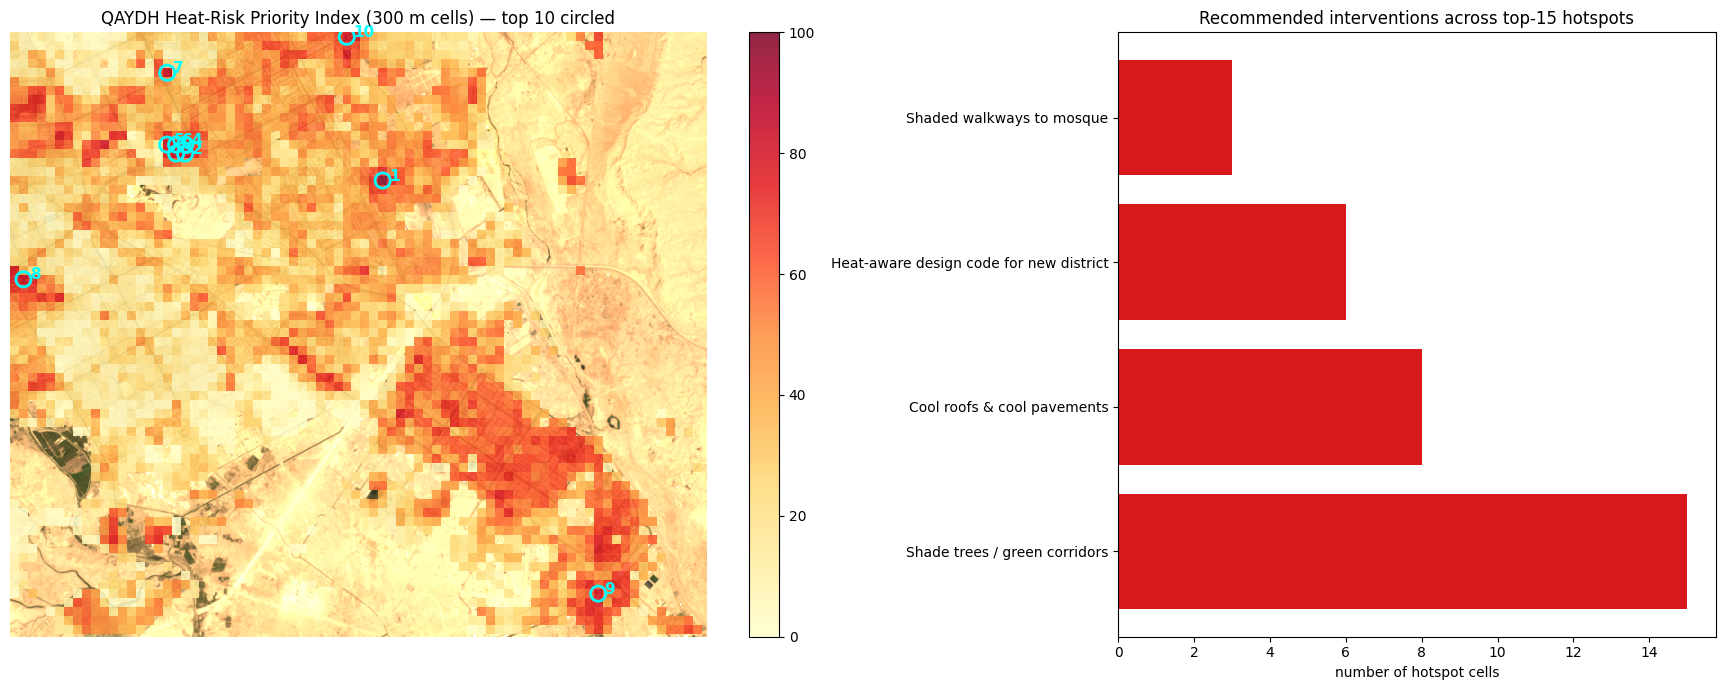

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw=dict(width_ratios=[1.4, 1]))
ax[0].imshow(rgb(comps[YEAR_AFTER]), extent=(0, SHAPE[1], SHAPE[0], 0));
im = ax[0].imshow(np.ma.masked_invalid(SCORE), cmap="YlOrRd", alpha=0.85, extent=(0, w * f, h * f, 0), vmin=0, vmax=100)
ax[0].scatter((cc[:10] + .5) * f, (rr[:10] + .5) * f, s=120, facecolors="none", edgecolors="cyan", lw=2)
for k in range(10): ax[0].text((cc[k] + 1.2) * f, (rr[k] + .5) * f, str(k + 1), color="cyan", fontsize=11, weight="bold")
ax[0].set_title("QAYDH Heat-Risk Priority Index (300 m cells) — top 10 circled"); ax[0].axis("off"); plt.colorbar(im, ax=ax[0], fraction=0.04)
acts = HOT.recommended_action.str.split(" + ", regex=False).explode().value_counts()
ax[1].barh(acts.index, acts.values, color="#d7191c"); ax[1].set_title("Recommended interventions across top-15 hotspots")
ax[1].set_xlabel("number of hotspot cells")
plt.tight_layout(); save_fig("06_heat_risk_priority"); plt.show()

## 9 · Exports for the dashboard: GeoJSON, interactive map, provenance, results

In [20]:
import geopandas as gpd, folium
from shapely.geometry import box
polys, attrs = [], []
for r_ in range(h):
    for c_ in range(w):
        if not np.isfinite(SCORE[r_, c_]): continue
        x0, y0 = TR * (c_ * f, r_ * f); x1, y1 = TR * ((c_ + 1) * f, (r_ + 1) * f)
        polys.append(box(min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)))
        attrs.append(dict(HRPI=float(SCORE[r_, c_]), LST_C=float(C["lst"][r_, c_]), built=float(C["built_frac"][r_, c_]),
                          green=float(C["green_frac"][r_, c_]), new=float(C["new_frac"][r_, c_]),
                          dark=None if not np.isfinite(C["dark_frac"][r_, c_]) else float(C["dark_frac"][r_, c_]),
                          people=float(np.nan_to_num(C["pop"][r_, c_])), exposure=float(np.nan_to_num(C["expo"][r_, c_])),
                          **{k: int(C[k][r_, c_]) for k in POI_KEYS}))
G = gpd.GeoDataFrame(attrs, geometry=polys, crs=CRS_DST.to_string()).to_crs(4326)
G["action"] = [recommend(dict(green_frac=a["green"], new_frac=a["new"], dark_frac=a["dark"] if a["dark"] is not None else np.nan,
                               **{k: a[k] for k in POI_KEYS})) for a in attrs]
G = G.round(3)
G.to_file(f"{OUT}/qaydh_heat_risk_cells.geojson", driver="GeoJSON")

fm = folium.Map(location=[LAT0, LON0], zoom_start=11, tiles="OpenStreetMap")
import branca.colormap as bcm
cm_ = bcm.linear.YlOrRd_09.scale(0, 100); cm_.caption = "QAYDH Heat-Risk Priority Index"
folium.GeoJson(G.to_json(), style_function=lambda ft: dict(fillColor=cm_(ft["properties"]["HRPI"]), fillOpacity=0.7, weight=0),
               tooltip=folium.GeoJsonTooltip(["HRPI", "LST_C", "people", "built", "green", "new", "mosque", "bus_stop", "delivery", "construction", "action"])).add_to(fm)
poi_style = {"mosque": ("green", "moon-o"), "bus_stop": ("blue", "bus"), "delivery": ("orange", "motorcycle"),
             "construction": ("darkred", "wrench"), "vulnerable": ("purple", "plus")}
for k, (col, icon) in poi_style.items():
    fg = folium.FeatureGroup(name=f"OSM: {k.replace('_', ' ')}", show=False)
    for _, p in POIS[POIS.cat == k].iterrows():
        folium.CircleMarker([p.lat, p.lon], radius=3, color=col, fill=True, tooltip=f"{k}: {p['name']}").add_to(fg)
    fg.add_to(fm)
folium.LayerControl(collapsed=False).add_to(fm)
cm_.add_to(fm)
for _, r_ in HOT.head(10).iterrows():
    folium.Marker([r_.lat, r_.lon], tooltip=f"#{r_['rank']} · LST {r_.LST_C:.1f} °C · {r_.recommended_action}",
                  icon=folium.Icon(color="red", icon="fire")).add_to(fm)
fm.save(f"{OUT}/qaydh_interactive_map.html"); display(fm)

json.dump(PROV, open(f"{OUT}/data_provenance.json", "w"), indent=2, default=str)
json.dump(RESULTS, open(f"{OUT}/results.json", "w"), indent=2, default=lambda o: float(o) if np.isscalar(o) else str(o))
print("Saved:", sorted(os.listdir(OUT)))

Saved: ['01_urban_expansion.png', '02_heat_hazard.png', '03_hyperspectral_materials.png', '04_albedo_agreement.png', '05_heat_drivers.png', '06_heat_risk_priority.png', '07_people_exposure.png', 'data_provenance.json', 'qaydh_heat_risk_cells.geojson', 'qaydh_interactive_map.html', 'results.json', 'top_hotspots.csv']


## 10 · Results card (copy these numbers into the pitch)

In [21]:
R_ = RESULTS; z = {d["zone"]: d["mean_LST"] for d in R_["lst_by_zone"]}
new_k = [k for k in z if k.startswith("New")]; old_k = [k for k in z if k.startswith("Established")]
print(f'''
QAYDH · Team {TEAM} · AOI centred {LAT0:.3f}N {LON0:.3f}E
────────────────────────────────────────────────────────────
URBAN EXPANSION   {R_["built_km2_before"]:.0f} km² ({YEAR_BEFORE}) → {R_["built_km2_after"]:.0f} km² ({YEAR_AFTER})  (+{R_["growth_pct"]:.0f}%)
                  confident new urban land: {R_["new_urban_km2"]:.0f} km²
CLASSIFIER        built-up F1 (spatial-block CV): {R_["cv_built_f1_rf"]:.2f} vs official NDBI rule {R_["cv_built_f1_ndbi"]:.2f}
                  independent IO-LULC {YEAR_INDEP}: F1 {R_["indep2023_built_f1_rf"]:.2f} vs {R_["indep2023_built_f1_ndbi"]:.2f}
                  change agreement {YEAR_CHG_REF}→{YEAR_INDEP}: F1 {R_["change_agreement_2017_2023"]["f1"]:.2f}
HEAT              mean summer LST: ''' + " | ".join(f"{k}: {v:.1f} °C" for k, v in z.items()) + f'''
                  new vs established urban: {(z[new_k[0]] - z[old_k[0]]) if new_k and old_k else float("nan"):+.1f} °C
HYPERSPECTRAL     Tanager↔Landsat albedo r = {R_["coreg_r_after"]:.2f}
                  ΔR² for LST from adding Tanager: all {R_.get("dR2_all", float("nan")):+.3f} | built-up {R_.get("dR2_built", float("nan")):+.3f}
COOLING WHAT-IF   +0.10 albedo ⇒ {R_["cooling_per_0p1_albedo_C"][0]:+.2f} °C (95% CI {R_["cooling_per_0p1_albedo_C"][1]:+.2f}…{R_["cooling_per_0p1_albedo_C"][2]:+.2f})
DECISION PRODUCT  {R_["n_priority_cells_top_decile"]} top-decile 300 m cells; top-20 stable under re-weighting: {min(R_["hrpi_top20_overlap"].values())*100:.0f}–{max(R_["hrpi_top20_overlap"].values())*100:.0f}%
''')
print("PEOPLE EXPOSED    " + f"{R_['people_in_top_decile_cells']:,.0f} residents live in the hottest 10% of populated cells (of {R_['population_aoi']:,.0f} in the AOI)")
g_ = R_["amenities_per_10k_hot_vs_rest"]
print("SERVICE GAP       per 10k residents, hottest 20% vs rest: " + " | ".join(f"{k} {v['hottest_20pct']:.2f} vs {v['rest_of_city']:.2f}" for k, v in g_.items()))
print("                  " + f"top-20 priorities changed by counting people instead of buildings: {R_['top20_changed_by_people_layer_pct']:.0f}%")



QAYDH · Team T0049 · AOI centred 24.576N 46.856E
────────────────────────────────────────────────────────────
URBAN EXPANSION   167 km² (2014) → 214 km² (2025)  (+28%)
                  confident new urban land: 33 km²
CLASSIFIER        built-up F1 (spatial-block CV): 0.89 vs official NDBI rule 0.58
                  independent IO-LULC 2023: F1 0.86 vs 0.58
                  change agreement 2017→2023: F1 0.29
HEAT              mean summer LST: Desert / bare: 51.8 °C | Vegetation: 50.4 °C | Established urban (built ≤2014): 52.2 °C | New urban (2014–2025): 51.9 °C
                  new vs established urban: -0.3 °C
HYPERSPECTRAL     Tanager↔Landsat albedo r = 0.87
                  ΔR² for LST from adding Tanager: all +0.087 | built-up +0.131
COOLING WHAT-IF   +0.10 albedo ⇒ -0.70 °C (95% CI -0.85…-0.56)
DECISION PRODUCT  301 top-decile 300 m cells; top-20 stable under re-weighting: 60–100%

PEOPLE EXPOSED    80,469 residents live in the hottest 10% of populated cells (of 1,091,324 in

## 11 · Limitations & honest validation notes (judges: we know where the edges are)
* **LST is surface temperature, not air temperature.** It is a strong proxy for heat stress but not the same thing. Incubation step: calibrate against NCM/municipal weather stations.
* **Labels are reference maps, not field truth.** WorldCover and IO LULC have their own errors, especially for low-density suburbs on sand. Incubation step: a few hundred photo-interpreted points from VHR imagery.
* **The cooling what-if is statistical** (a cross-sectional slope with block-bootstrap CI), not a physical simulation. It ranks options; it does not guarantee degrees.
* **People exposure uses WorldPop (night-time residents) and OpenStreetMap places.** OSM is incomplete in parts of the Gulf, and labour accommodation and delivery-rider waiting spots are under-mapped. Incubation step: municipal POI registers, delivery-platform hub locations and labour-camp registers.
* **Landsat LST is a ~10:30 local-time snapshot.** Peak air temperature comes later in the afternoon, so LST ranks places reliably but does not give the day's maximum.
* **Tanager is a single acquisition, and it is not on the same day as Landsat.** Materials are stable, but shadows and seasonal greenery are not. With 813 / MBZ-SAT or commercial Tanager in incubation, the same pipeline runs repeatedly per city.
* **Data rules respected:** only open data, licences recorded in `data_provenance.json`, and no imagery committed to GitHub (only code and derived outputs).